## 📁 Dataset Columns Explained

| 🏷️ Column Name     | 📝 Description                                                                 |
|--------------------|---------------------------------------------------------------------------------|
| **Age**            | Patient's age (in years)                                                        |
| **Salt_Intake**    | Daily salt intake (in grams) – a major contributor to high BP                   |
| **Stress_Score**   | Scale of 0–10 measuring psychological stress level                              |
| **BP_History**     | Previous blood pressure status: Normal, Prehypertension, Hypertension           |
| **Sleep_Duration** | Average sleep hours per day                                                     |
| **BMI**            | Body Mass Index (weight/height-based obesity measure)                           |
| **Medication**     | Medication type: None, Beta Blocker, Diuretic, ACE Inhibitor, Other             |
| **Family_History** | Family history of hypertension: Yes / No                                        |
| **Exercise_Level** | Physical activity level: Low, Moderate, High                                    |
| **Smoking_Status** | Whether the patient is a Smoker or Non-Smoker                                   |
| **Has_Hypertension** | Target variable: Indicates presence of hypertension (Yes/No)                 |

## Import Library

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv(r"...\DataSet\hypertension_dataset.csv")
pd.set_option('display.max_columns', None)

## Little bit Information from DataSet

In [3]:
df

,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
0,69,8.0,9,Normal,6.4,25.8,NaN,Yes,Low,Non-Smoker,Yes
1,32,11.7,10,Normal,5.4,23.4,NaN,No,Low,Non-Smoker,No
2,78,9.5,3,Normal,7.1,18.7,NaN,No,Moderate,Non-Smoker,No
3,38,10.0,10,Hypertension,4.2,22.1,ACE Inhibitor,No,Low,Non-Smoker,Yes
4,41,9.8,1,Prehypertension,5.8,16.2,Other,No,Moderate,Non-Smoker,No
...,...,...,...,...,...,...,...,...,...,...,...
1980,56,10.2,0,Normal,6.5,25.0,Diuretic,Yes,Low,Non-Smoker,Yes
1981,29,8.9,4,Hypertension,6.9,16.9,NaN,Yes,High,Non-Smoker,Yes
1982,64,5.9,9,Normal,5.6,18.9,ACE Inhibitor,Yes,Moderate,Non-Smoker,Yes
1983,35,7.4,8,Prehypertension,8.2,29.2,NaN,Yes,Moderate,Non-Smoker,No


In [4]:
df.shape

(1985, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1985 entries, 0 to 1984
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1985 non-null   int64  
 1   Salt_Intake       1985 non-null   float64
 2   Stress_Score      1985 non-null   int64  
 3   BP_History        1985 non-null   object 
 4   Sleep_Duration    1985 non-null   float64
 5   BMI               1985 non-null   float64
 6   Medication        1186 non-null   object 
 7   Family_History    1985 non-null   object 
 8   Exercise_Level    1985 non-null   object 
 9   Smoking_Status    1985 non-null   object 
 10  Has_Hypertension  1985 non-null   object 
dtypes: float64(3), int64(2), object(6)
memory usage: 170.7+ KB


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.columns

Index(['Age', 'Salt_Intake', 'Stress_Score', 'BP_History', 'Sleep_Duration',
       'BMI', 'Medication', 'Family_History', 'Exercise_Level',
       'Smoking_Status', 'Has_Hypertension'],
      dtype='object')

In [8]:
df.isnull().sum()

Age                   0
Salt_Intake           0
Stress_Score          0
BP_History            0
Sleep_Duration        0
BMI                   0
Medication          799
Family_History        0
Exercise_Level        0
Smoking_Status        0
Has_Hypertension      0
dtype: int64

from checking null value, as we can see, in the dataset have null value in the 'MEdication' column, in my opinion with seeing in the unique value, this column has no impact to model. maybe we can considering to drop this column?

### Check Unique Value for 'Object' Column

In [9]:
cols = df.select_dtypes('object')

for col in cols:
    print(f"Unique Val in Column {col}:")
    print(df[col].unique())
    print()

Unique Val in Column BP_History:
['Normal' 'Hypertension' 'Prehypertension']

Unique Val in Column Medication:
[nan 'ACE Inhibitor' 'Other' 'Beta Blocker' 'Diuretic']

Unique Val in Column Family_History:
['Yes' 'No']

Unique Val in Column Exercise_Level:
['Low' 'Moderate' 'High']

Unique Val in Column Smoking_Status:
['Non-Smoker' 'Smoker']

Unique Val in Column Has_Hypertension:
['Yes' 'No']



after checking the unique Value for every column with type 'object', i decide to drop column 'Medication'. <br>
after that is encoded the value for every object column. <br>
the dataset is also contain good value, no need to cleansing value.

## Explore Data Analysis

In [10]:
df_EDA = df.copy()

In [11]:
df_EDA.sample(5)

,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
747,30,11.2,1,Hypertension,7.6,23.1,NaN,No,Moderate,Non-Smoker,Yes
776,54,10.3,0,Hypertension,4.7,21.7,NaN,Yes,High,Non-Smoker,Yes
349,39,5.6,5,Hypertension,4.8,18.9,Beta Blocker,No,Moderate,Smoker,Yes
62,32,10.5,6,Normal,8.1,38.1,Beta Blocker,Yes,Moderate,Non-Smoker,Yes
1577,71,5.7,9,Prehypertension,4.3,27.0,NaN,Yes,Low,Non-Smoker,Yes


In [12]:
df_EDA = df_EDA.drop(columns='Medication')

### 🔍 Descriptif Statistic

In [13]:
# Tampilkan statistik deskriptif
df_EDA.describe()[['Age', 'Salt_Intake', 'Stress_Score', 'Sleep_Duration', 'BMI']]

,Age,Salt_Intake,Stress_Score,Sleep_Duration,BMI
count,1985.000000,1985.000000,1985.000000,1985.000000,1985.000000
mean,50.341058,8.531688,4.979345,6.452242,26.015315
std,19.442042,1.994907,3.142303,1.542207,4.512857
min,18.000000,2.500000,0.000000,1.500000,11.900000
25%,34.000000,7.200000,2.000000,5.400000,23.000000
50%,50.000000,8.500000,5.000000,6.500000,25.900000
75%,67.000000,9.900000,8.000000,7.500000,29.100000
max,84.000000,16.400000,10.000000,11.400000,41.900000


##### Vizulitation 

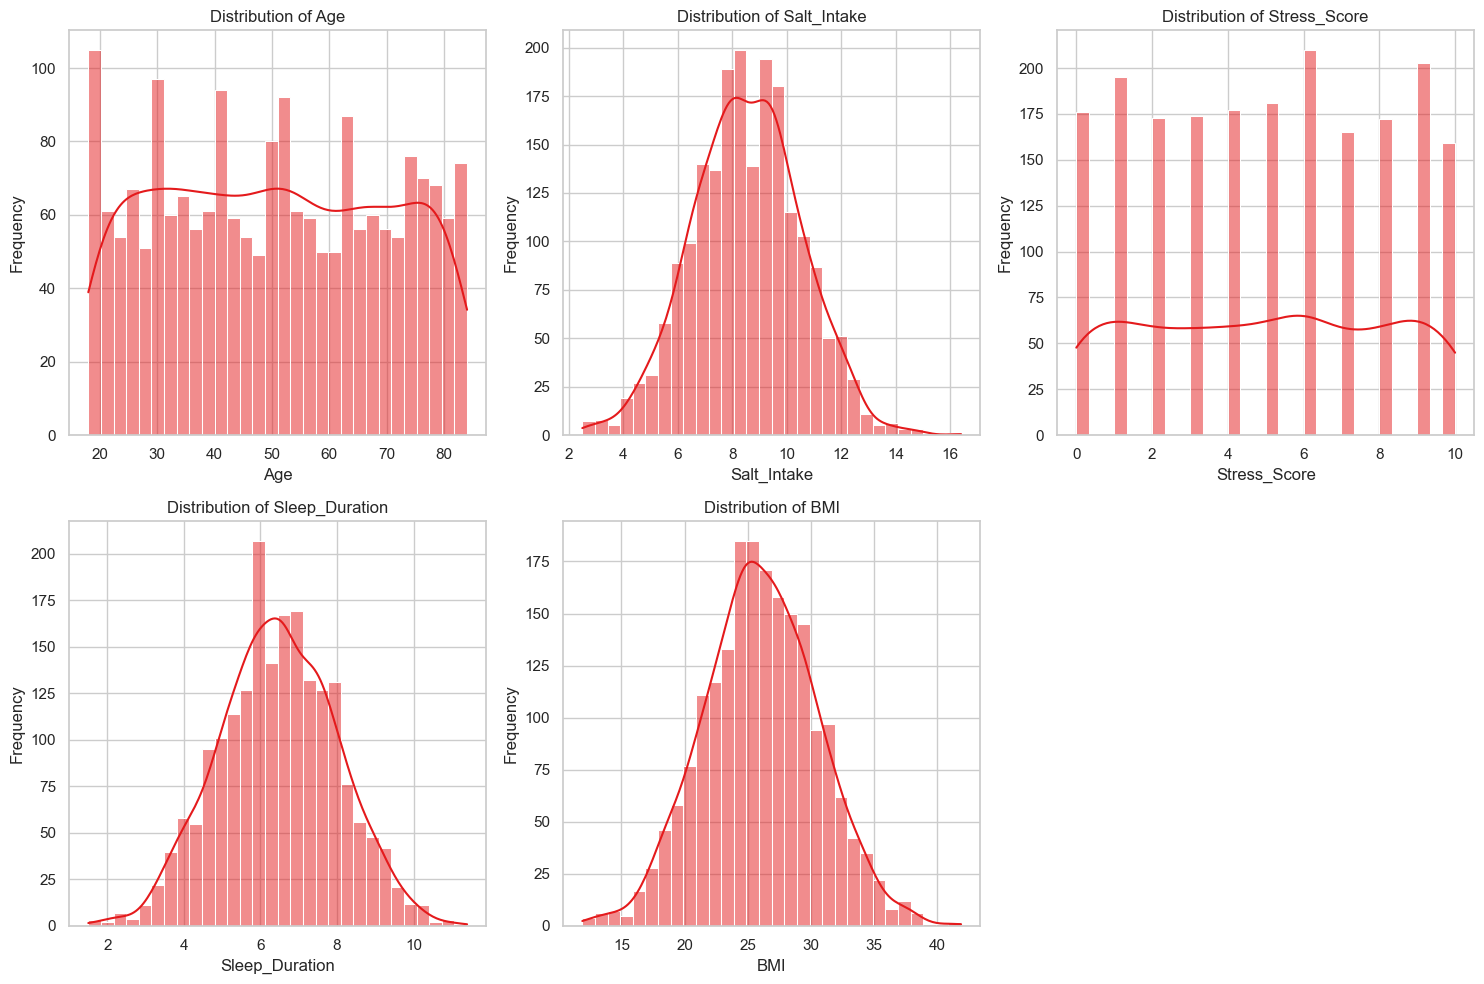

In [14]:
# set style
sns.set(style="whitegrid", palette="Set1")

num_col = df_EDA.select_dtypes(['int64', 'float64'])

#subplot
plt.figure(figsize=(15,10))
for i, col in enumerate(num_col, 1):
    plt.subplot(2,3, i)
    sns.histplot(df_EDA[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### 📉 Analisis Univariate

pada numerical kolom sudah kita visualisasikan, secar untuk categorical kolom kita akan visualisasikan

In [15]:
# categorical column
cat_cols = df_EDA.select_dtypes('object')

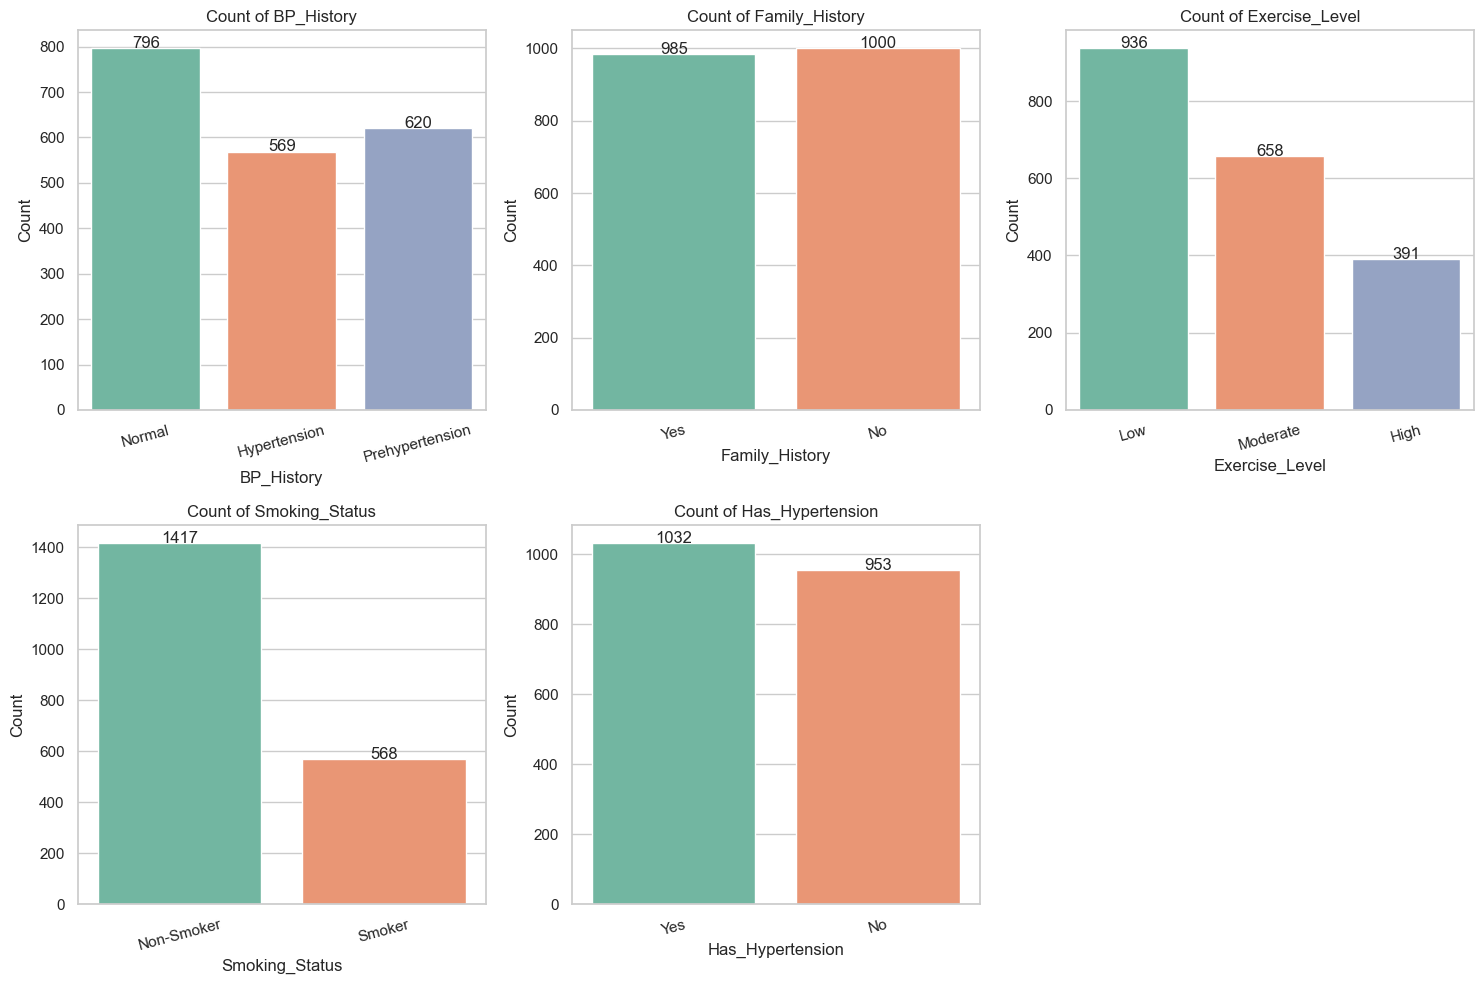

In [16]:
# Visualisasi bar plot
plt.figure(figsize=(15, 10))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 3, i)
    ax = sns.countplot(data=df_EDA, x=col, hue=col, palette="Set2", legend=False)
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=15)

    # add label for every bar plot
    for p in ax.patches:
        height = p.get_height()
        ax.text(
            p.get_x() + p.get_width() / 2.,
            height + 0.5,
            f'{int(height)}',
            ha="center"
        )

plt.tight_layout()
plt.show()

### 📊 Analisis Bivariate

#### 🔹Numerical vs Target

In [17]:
# Fitur numerik
num_cols = df_EDA.select_dtypes(['int64', 'float64'])

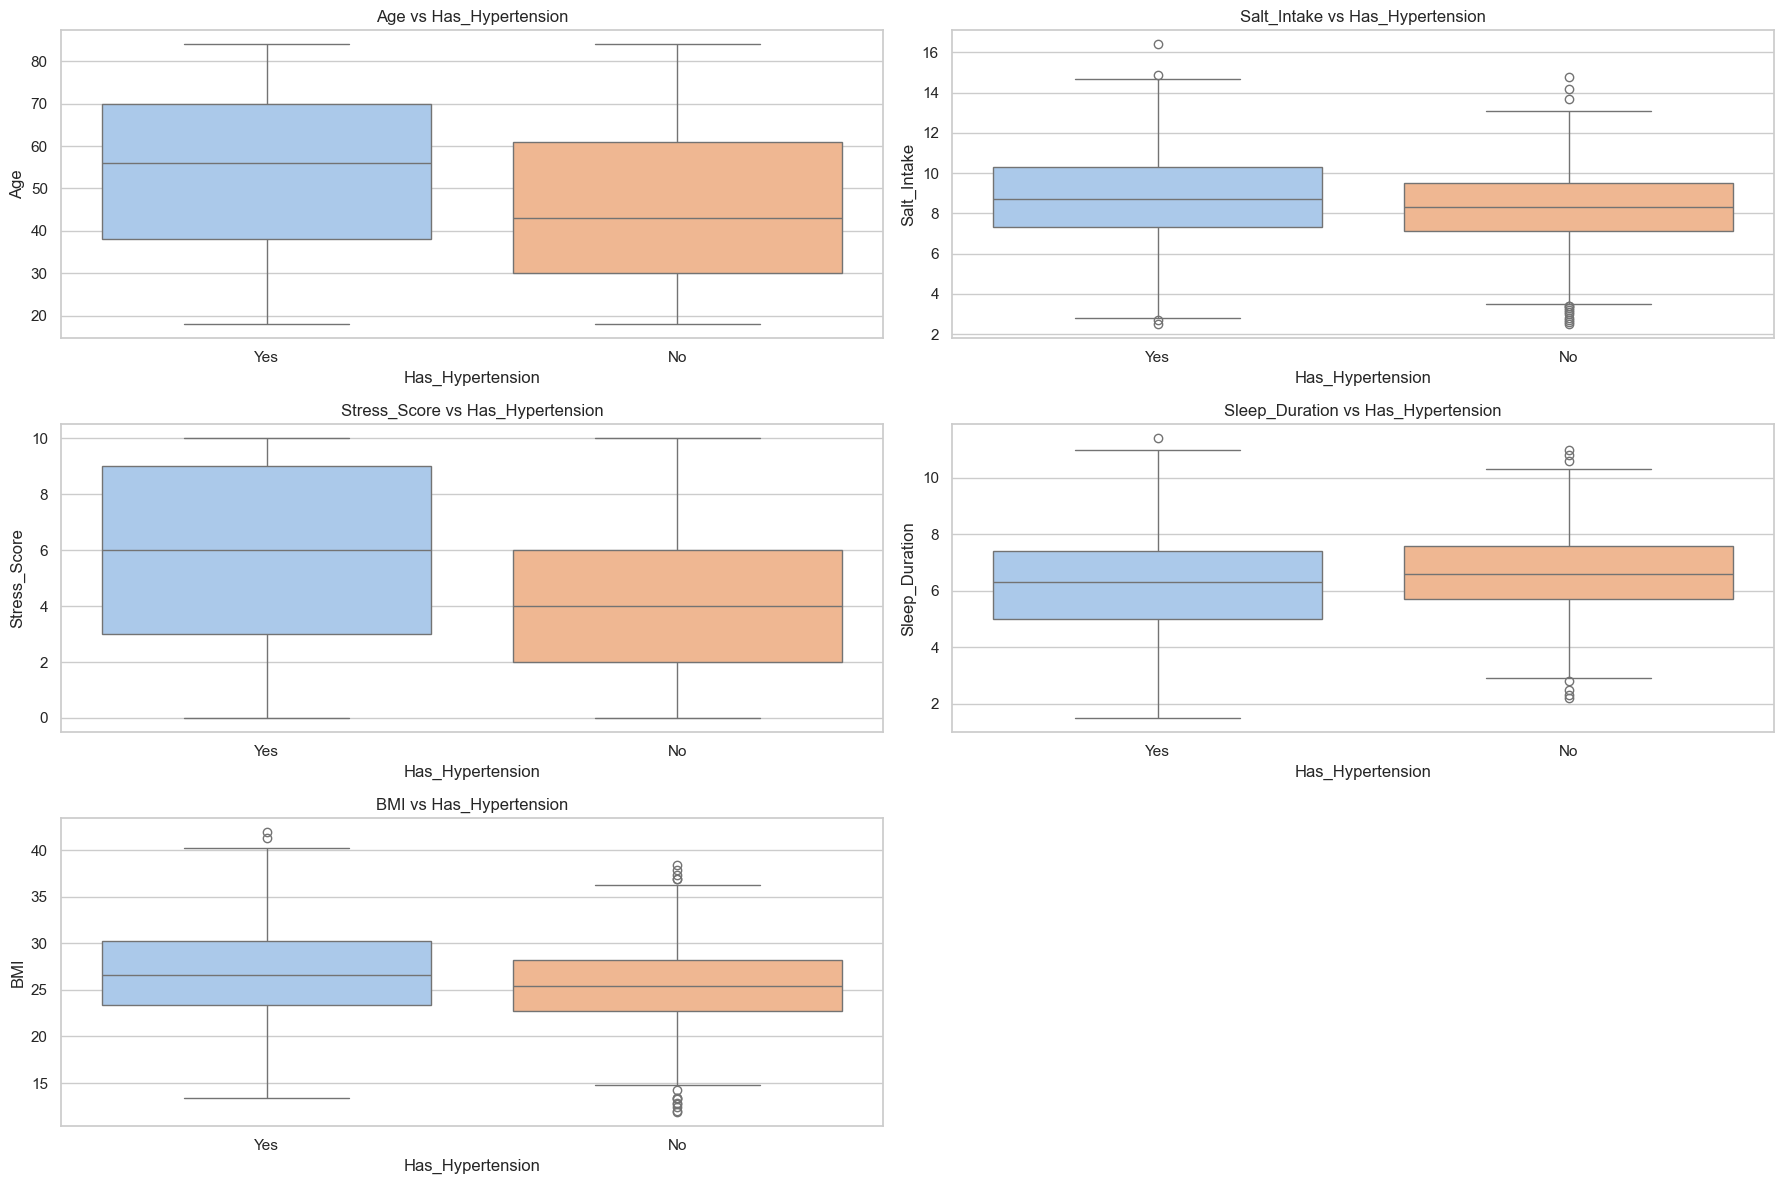

In [18]:
#Box Plot
plt.figure(figsize=(18, 12))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(data=df_EDA, x='Has_Hypertension', y=col, hue='Has_Hypertension', palette='pastel')
    plt.title(f'{col} vs Has_Hypertension')
    plt.xlabel('Has_Hypertension')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

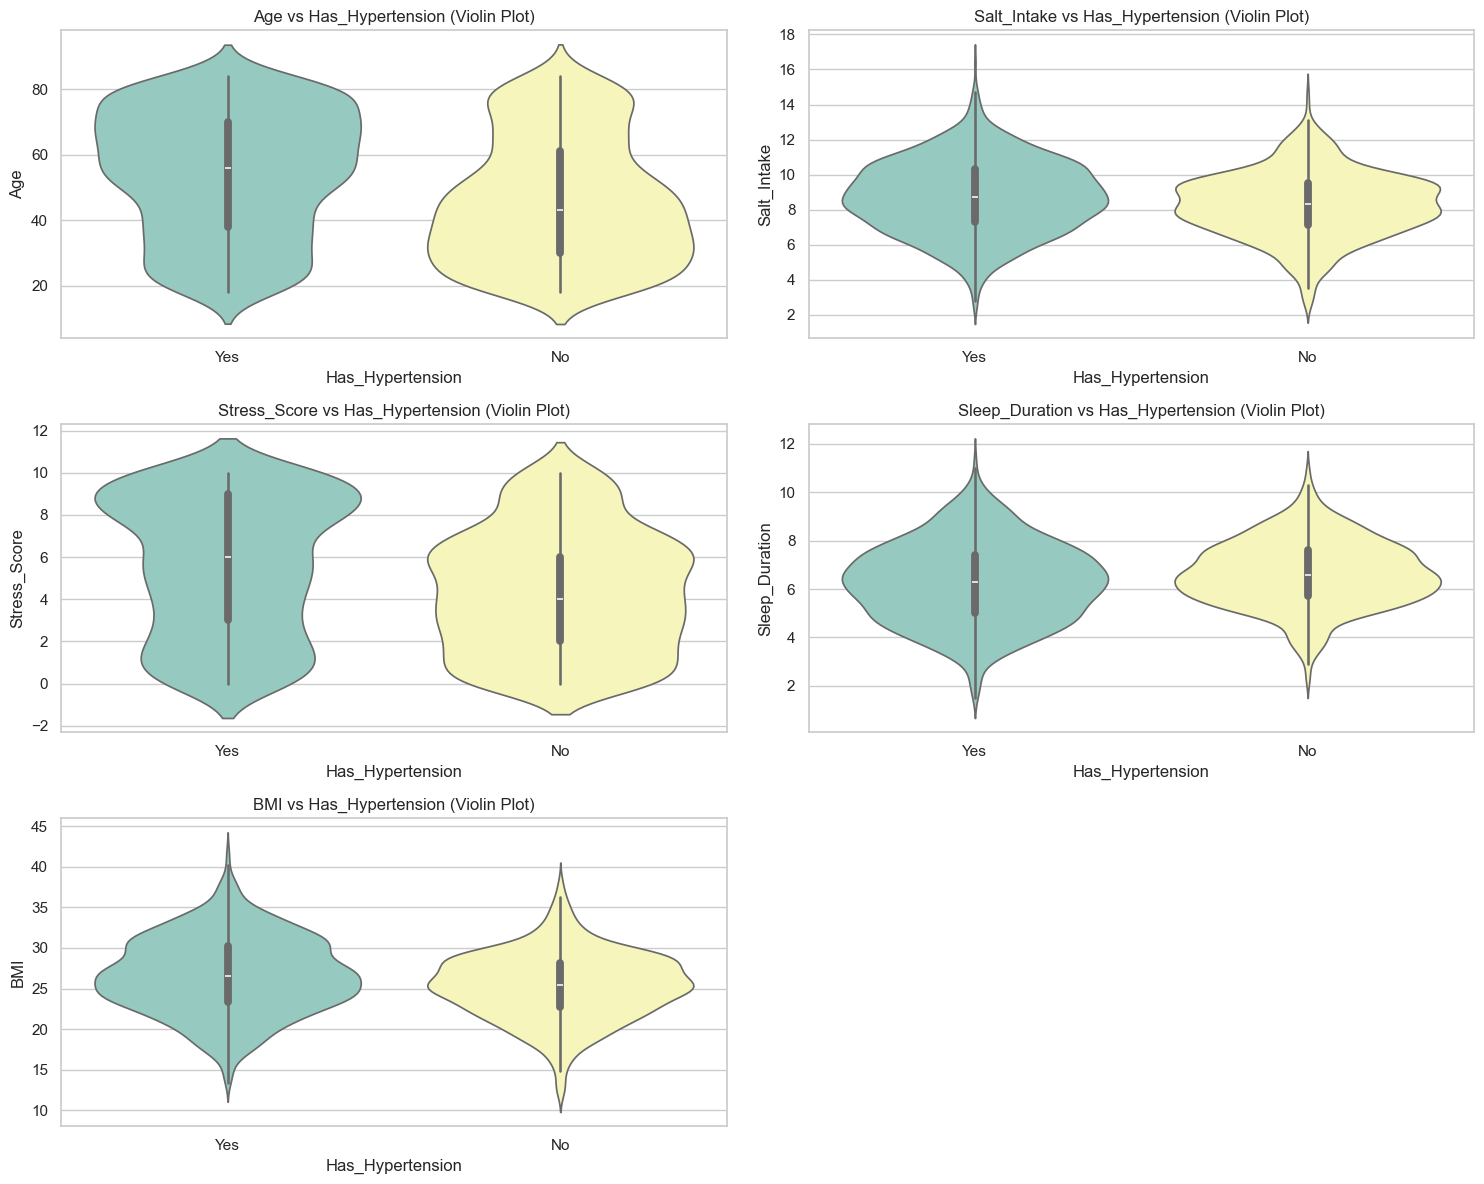

In [19]:
# VIolin Plot
plt.figure(figsize=(15, 12))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 2, i)
    sns.violinplot(data=df_EDA, x='Has_Hypertension', y=col, hue='Has_Hypertension', palette='Set3')
    plt.title(f'{col} vs Has_Hypertension (Violin Plot)')
    plt.xlabel('Has_Hypertension')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

#### 🔹Categorical vs Target

In [20]:
# Fitur kategorikal (tanpa Medication)
cat_cols = df_EDA.select_dtypes('object')

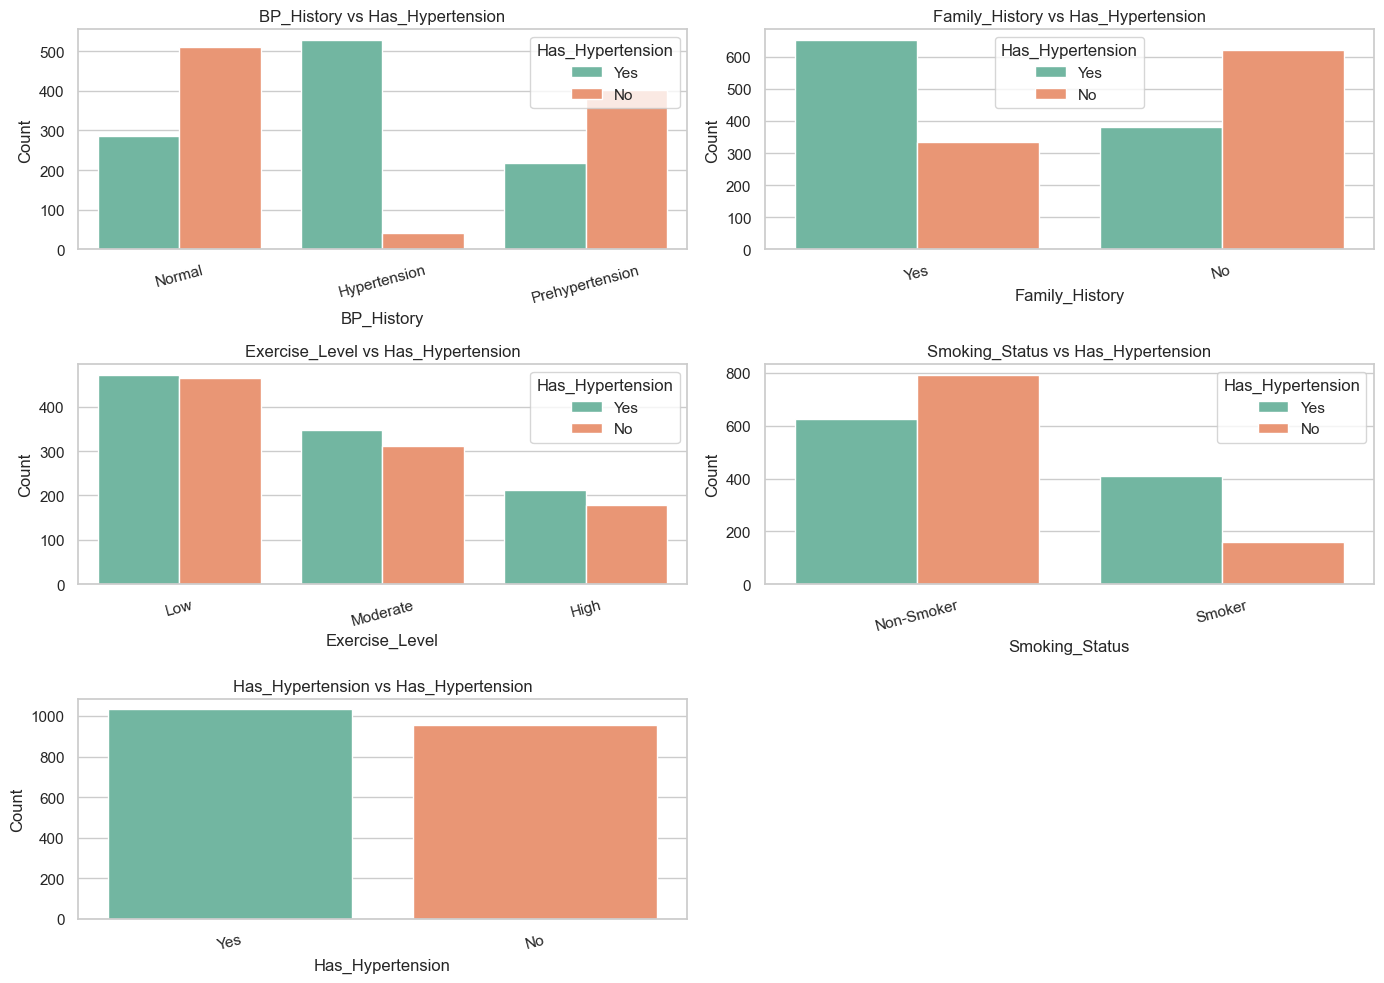

In [21]:
plt.figure(figsize=(14, 10))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(3, 2, i)
    sns.countplot(data=df_EDA, x=col, hue='Has_Hypertension', palette='Set2')
    plt.title(f'{col} vs Has_Hypertension')
    plt.xlabel(col)
    plt.ylabel('Count')
    # plt.legend(title='Has_Hypertension')
    plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

✅ Insight yang Bisa Dicari:
- Apakah nilai rata-rata Salt_Intake lebih tinggi pada pasien hipertensi?
- Apakah pasien dengan Low Exercise_Level cenderung memiliki hipertensi?
- Apakah Family_History kuat memengaruhi kemungkinan hipertensi?
- Bagaimana peran usia, stres, dan tidur?

### 🔗 Analisis Multivariat

#### 🔥Heatmap Korelasi (Numerik)

In [22]:
# Ubah target ke numerik (Yes=1, No=0) sementara untuk korelasi
df_corr = df_EDA.copy()
df_corr['Has_Hypertension'] = df_corr['Has_Hypertension'].map({'Yes': 1, 'No': 0})

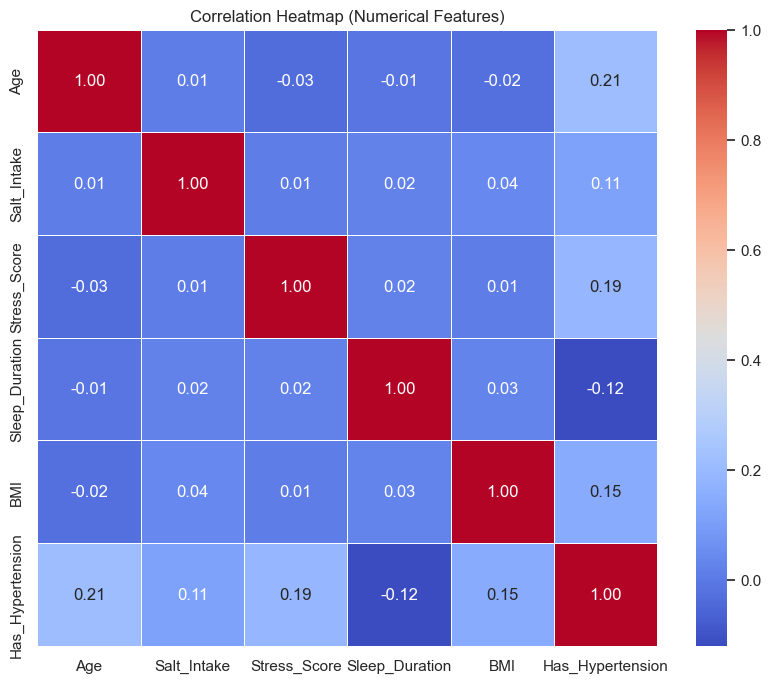

In [23]:
# Hitung korelasi
plt.figure(figsize=(10, 8))
sns.heatmap(df_corr.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()

#### 🌀 Pairplot (Numerik vs Target)

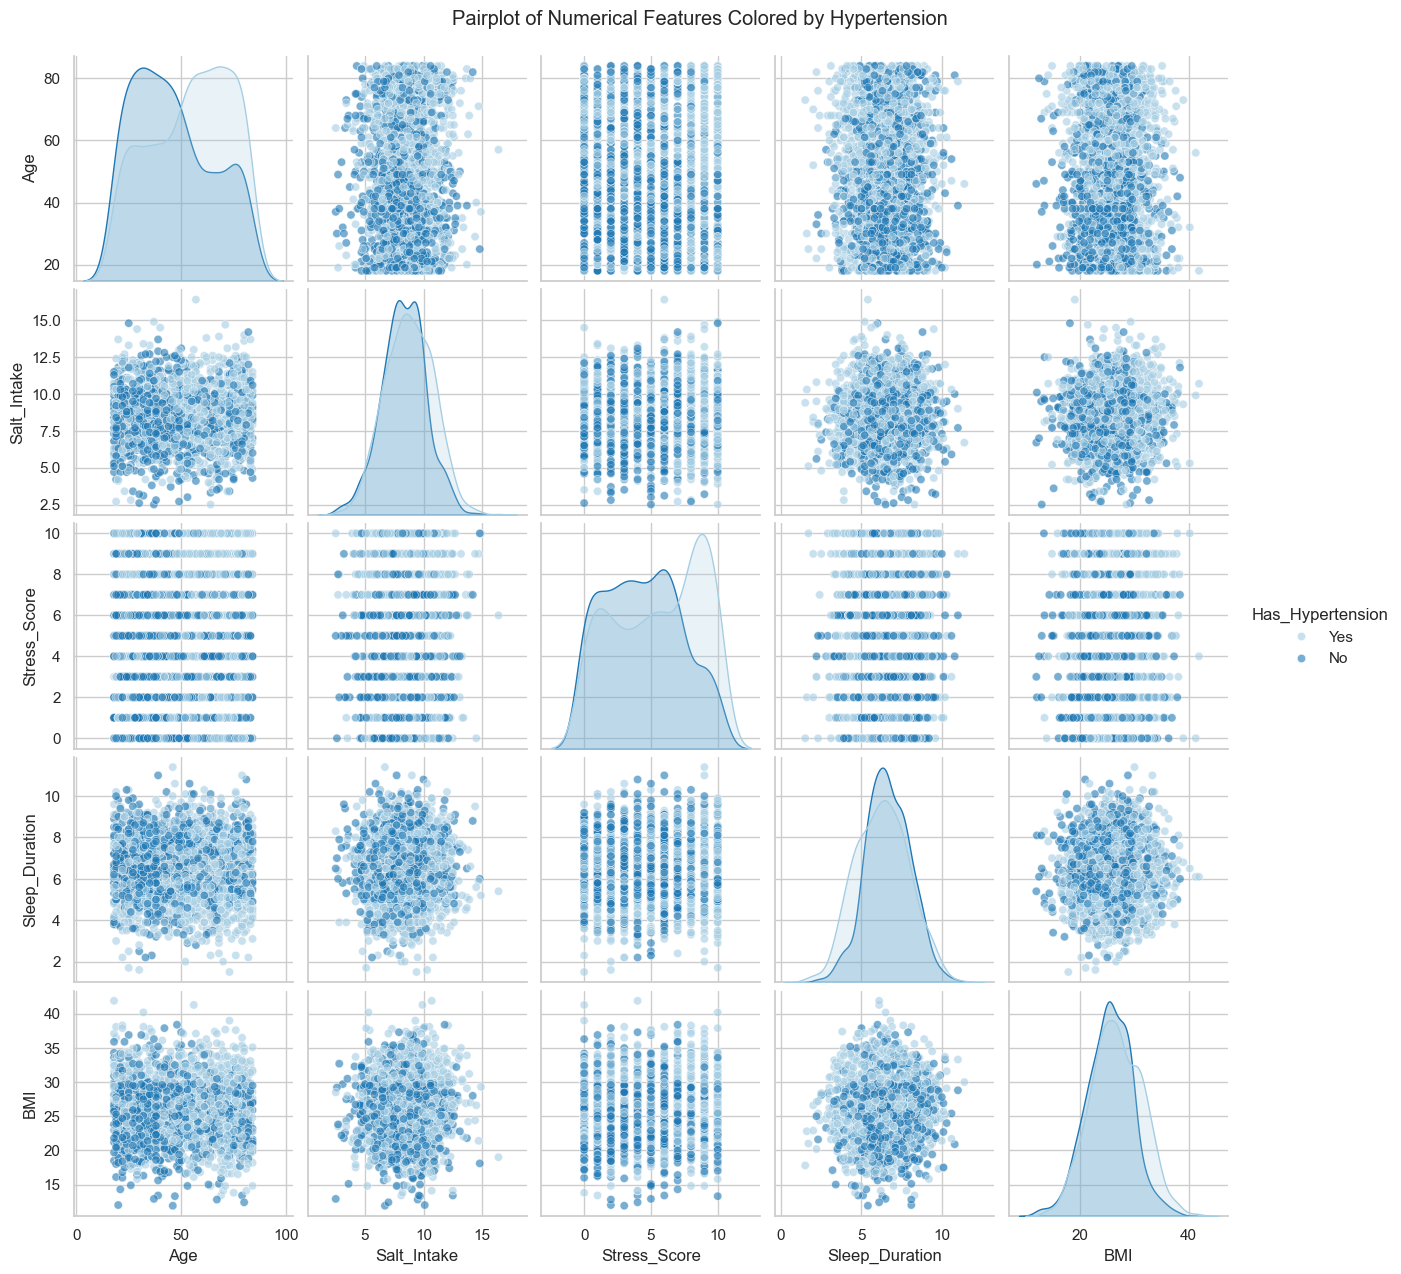

In [24]:
sns.pairplot(df_EDA, 
             vars=['Age', 'Salt_Intake', 'Stress_Score', 'Sleep_Duration', 'BMI'], 
             hue='Has_Hypertension', 
             palette='Paired', 
             diag_kind='kde', 
             plot_kws={'alpha': 0.6})
plt.suptitle("Pairplot of Numerical Features Colored by Hypertension", y=1.02)
plt.show()

#### 📊 Crosstab + Stacked Bar Plot

##### ➕ Crosstab & Barplot: Exercise_Level vs Smoking_Status vs Has_Hypertension

In [25]:
# Crosstab
cross_tab = pd.crosstab(
    [df_EDA['Exercise_Level'], df_EDA['Smoking_Status']], 
    df_EDA['Has_Hypertension'],
    normalize='index'  # persentase
)

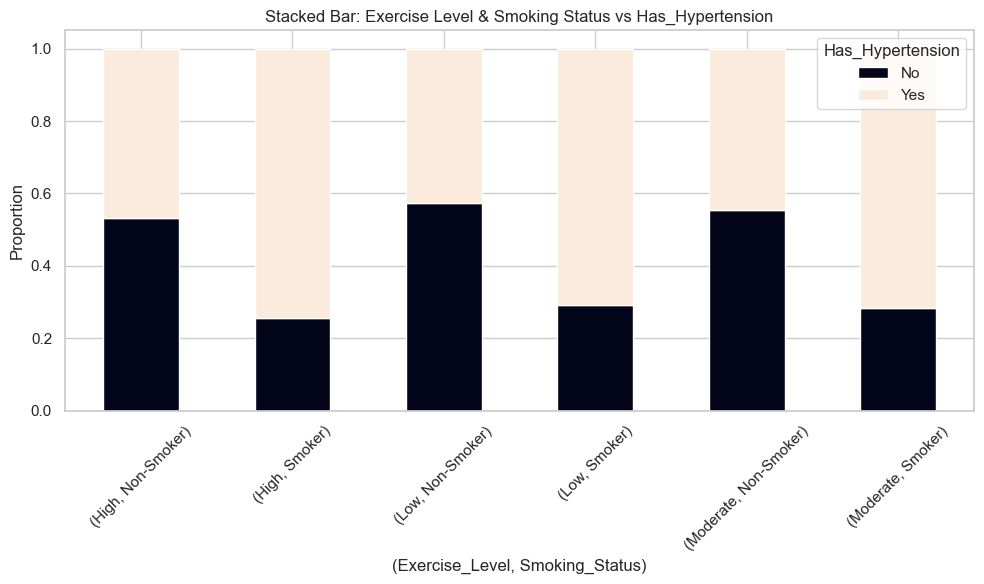

In [26]:
# Visualisasi
cross_tab.plot(kind='bar', stacked=True, colormap='rocket', figsize=(10, 6))
plt.title('Stacked Bar: Exercise Level & Smoking Status vs Has_Hypertension')
plt.ylabel('Proportion')
plt.xlabel('(Exercise_Level, Smoking_Status)')
plt.legend(title='Has_Hypertension')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### ➕ Crosstab & Barplot: BP_History vs Family_History vs Has_Hypertension

In [27]:
# Crosstab
cross_tab2 = pd.crosstab(
    [df_EDA['BP_History'], df_EDA['Family_History']], 
    df_EDA['Has_Hypertension'],
    normalize='index'
)

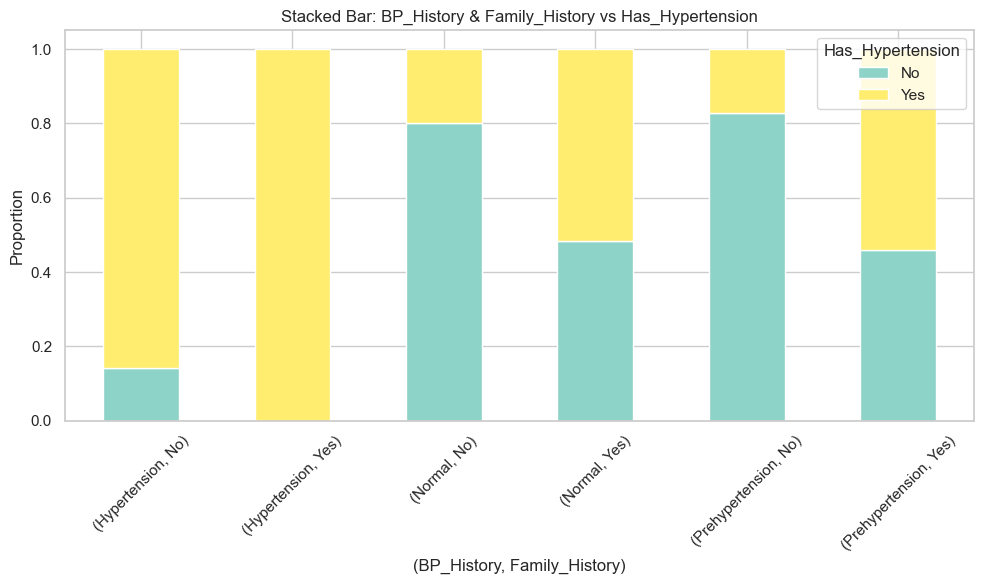

In [28]:
# Visualisasi
cross_tab2.plot(kind='bar', stacked=True, colormap='Set3', figsize=(10, 6))
plt.title('Stacked Bar: BP_History & Family_History vs Has_Hypertension')
plt.ylabel('Proportion')
plt.xlabel('(BP_History, Family_History)')
plt.legend(title='Has_Hypertension')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

✅ Insight yang Bisa Dicari
- Fitur mana yang saling berkorelasi kuat?
- Kelompok mana (gabungan kategori) yang lebih banyak memiliki hipertensi?
- Apakah kombinasi "Low exercise + Smoker" meningkatkan risiko?

### Analyze Based on "Domain"

#### 🔹 1. Apakah tinggi konsumsi garam berkaitan dengan hipertensi?
> Hipotesis: Pasien dengan hipertensi cenderung mengonsumsi lebih banyak garam.

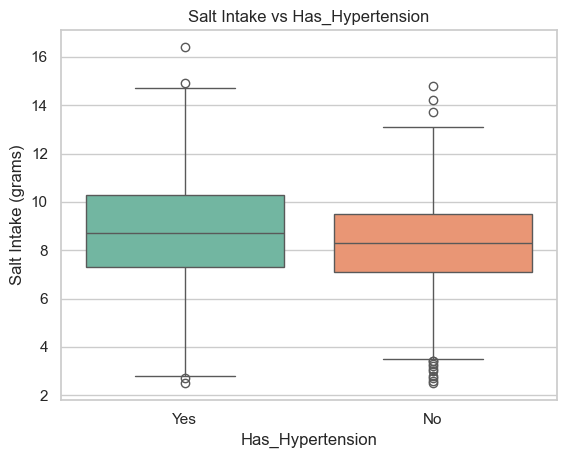

In [29]:
#Box Plot
sns.boxplot(data=df_EDA, x='Has_Hypertension', y='Salt_Intake', hue='Has_Hypertension', palette='Set2')
plt.title('Salt Intake vs Has_Hypertension')
plt.xlabel('Has_Hypertension')
plt.ylabel('Salt Intake (grams)')
plt.show()

In [30]:
# ✅ Rata-rata konsumsi garam berdasarkan status hipertensi
df_EDA.groupby('Has_Hypertension')['Salt_Intake'].mean()

Has_Hypertension
No     8.294229
Yes    8.750969
Name: Salt_Intake, dtype: float64

#### 🔹 2. Bagaimana tingkat stres berpengaruh terhadap tekanan darah?
> Hipotesis: Stres tinggi (nilai mendekati 10) meningkatkan risiko hipertensi.

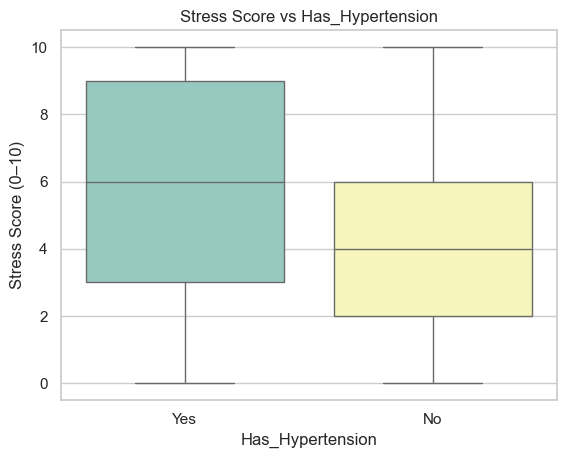

In [31]:
# Box Plot
sns.boxplot(data=df_EDA, x='Has_Hypertension', y='Stress_Score', hue='Has_Hypertension', palette='Set3')
plt.title('Stress Score vs Has_Hypertension')
plt.xlabel('Has_Hypertension')
plt.ylabel('Stress Score (0–10)')
plt.show()

In [32]:
df_EDA.groupby('Has_Hypertension')['Stress_Score'].mean()

Has_Hypertension
No     4.368311
Yes    5.543605
Name: Stress_Score, dtype: float64

#### 🔹 3. Apakah durasi tidur < 6 jam menunjukkan tren hipertensi?
> Hipotesis: Pasien yang tidur terlalu singkat memiliki kecenderungan lebih tinggi terkena hipertensi.

In [33]:
# ✅ Buat kolom kategorikal "Sleep_Category"
df_EDA['Sleep_Category'] = pd.cut(df_EDA['Sleep_Duration'],
                                  bins=[0, 5.9, 6.9, 8.9, 24],
                                  labels=['<6 hours', '6–7 hours', '8–9 hours', '>9 hours'])

In [34]:
# Crosstab sleep category vs Has_Hypertension
sleep_ct = pd.crosstab(df_EDA['Sleep_Category'], df_EDA['Has_Hypertension'], normalize='index')

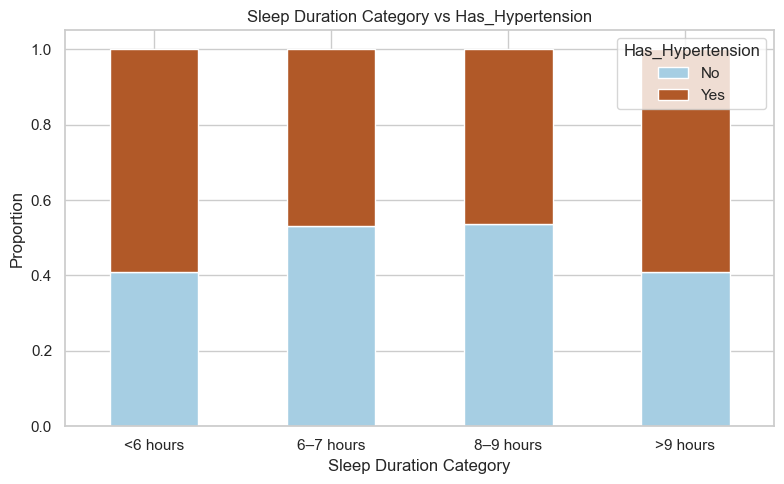

In [35]:
# Visualisasi
sleep_ct.plot(kind='bar', stacked=True, colormap='Paired', figsize=(8, 5))
plt.title('Sleep Duration Category vs Has_Hypertension')
plt.ylabel('Proportion')
plt.xlabel('Sleep Duration Category')
plt.legend(title='Has_Hypertension')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### 🔹 4. Apakah pasien dengan riwayat keluarga memiliki risiko lebih tinggi?
> Hipotesis: Ada hubungan kuat antara riwayat keluarga dan hipertensi.

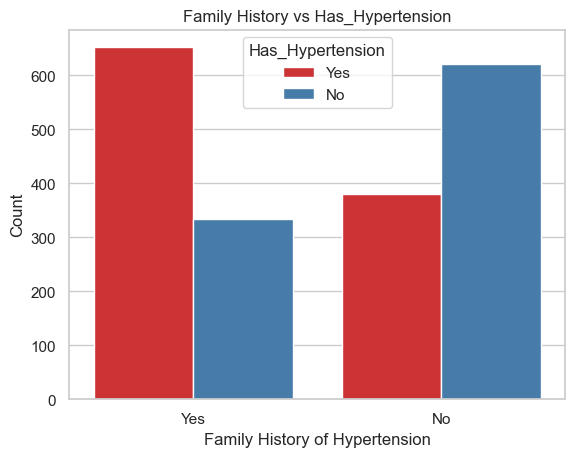

In [36]:
# BarPlot
sns.countplot(data=df_EDA, x='Family_History', hue='Has_Hypertension', palette='Set1')
plt.title('Family History vs Has_Hypertension')
plt.xlabel('Family History of Hypertension')
plt.ylabel('Count')
plt.legend(title='Has_Hypertension')
plt.show()

In [37]:
df_EDA.groupby('Family_History')['Has_Hypertension'].value_counts(normalize=True).unstack()

Has_Hypertension,No,Yes
Family_History,,
No,0.620000,0.380000
Yes,0.338071,0.661929


#### ✅ Summary Insight Sementara

| Analisis             | Potensi Insight                                                 |
| -------------------- | --------------------------------------------------------------- |
| Konsumsi garam       | Hipertensi mungkin lebih umum di kelompok konsumsi garam tinggi |
| Tingkat stres        | Skor stres lebih tinggi pada pasien hipertensi                  |
| Durasi tidur < 6 jam | Proporsi hipertensi lebih tinggi di kelompok tidur < 6 jam      |
| Riwayat keluarga     | Pasien dengan family history lebih sering memiliki hipertensi   |

### 🧹 Check Data Quality

#### 🧪 Outlier Detection (Numeric Column)

In [38]:
num_cols = ['Age', 'Salt_Intake', 'Stress_Score', 'Sleep_Duration', 'BMI']

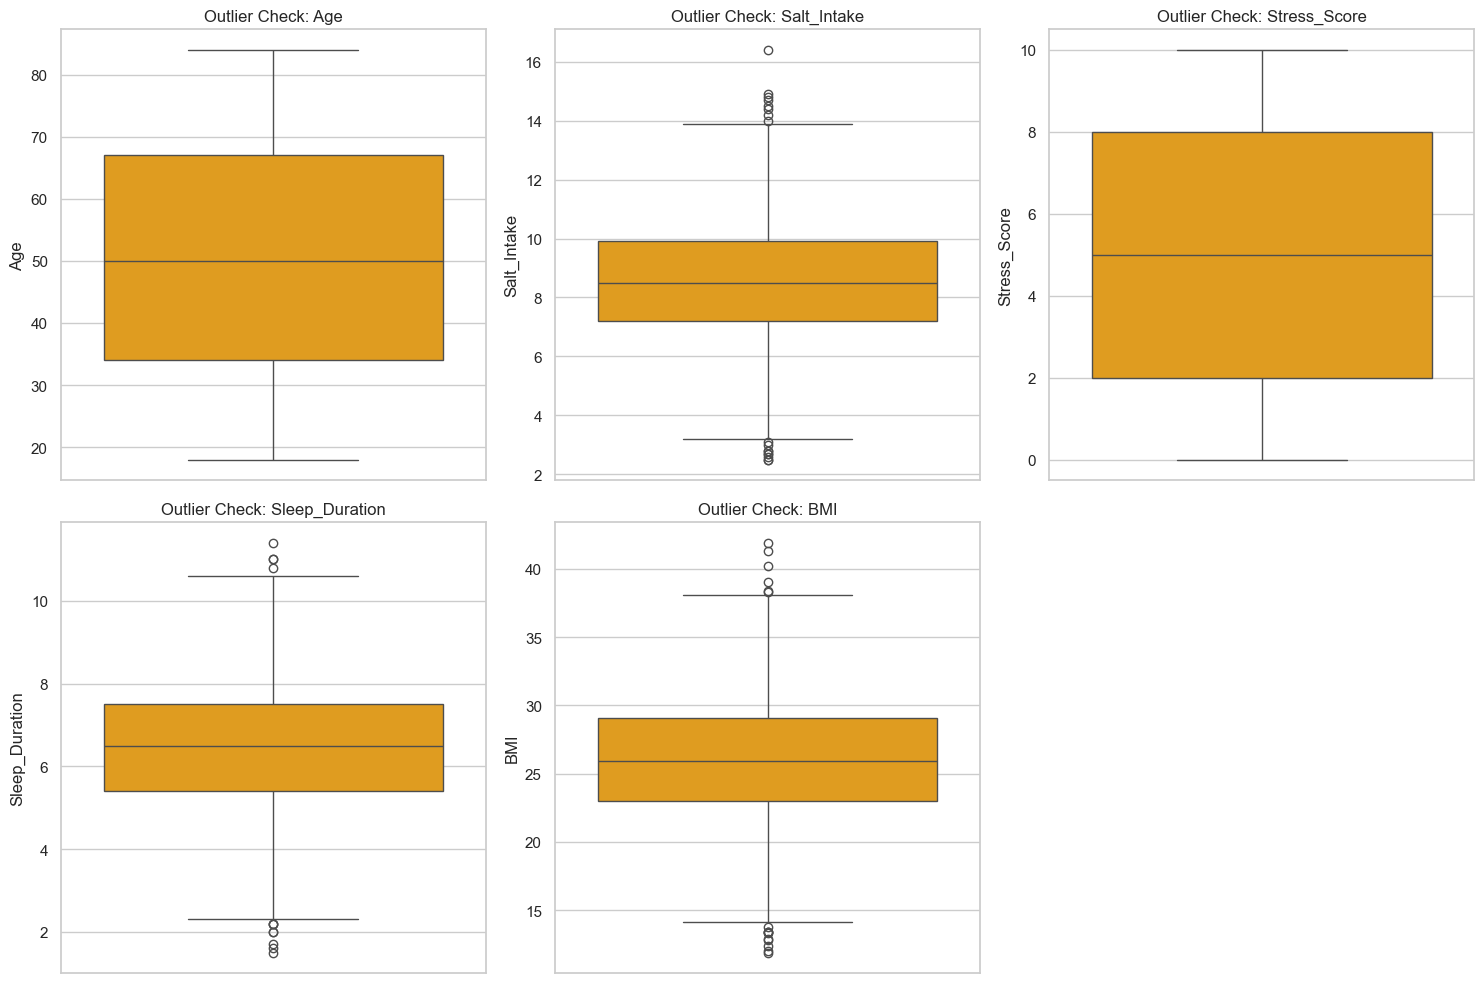

In [39]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df_EDA, y=col, color='orange')
    plt.title(f'Outlier Check: {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

In [40]:
# ✅ Cek Nilai Maksimum & Minimum

df_EDA[num_cols].describe().T[['min', 'max']]

,min,max
Age,18.0,84.0
Salt_Intake,2.5,16.4
Stress_Score,0.0,10.0
Sleep_Duration,1.5,11.4
BMI,11.9,41.9


🧠 Tips Identifikasi Outlier:
- Age: Normalnya < 100
- BMI: Biasanya antara 15 – 50 (BMI > 60 mencurigakan)
- Salt_Intake: > 20 gram per hari termasuk tinggi ekstrem
- Sleep_Duration: < 3 jam atau > 15 jam patut dicurigai

#### ⚖️ Cek Distribusi Target (Data Imbalance)

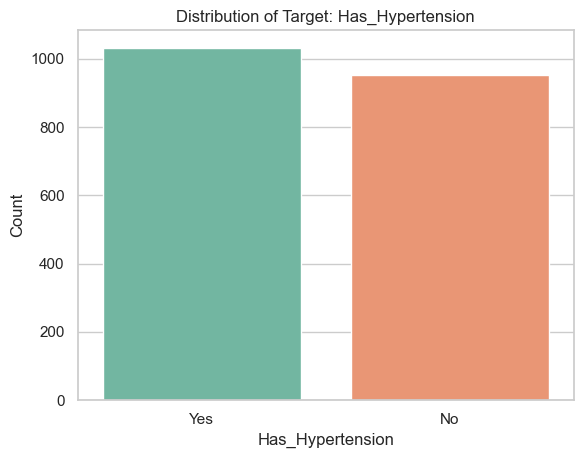

In [41]:
sns.countplot(data=df_EDA, x='Has_Hypertension', hue='Has_Hypertension', palette='Set2')
plt.title('Distribution of Target: Has_Hypertension')
plt.xlabel('Has_Hypertension')
plt.ylabel('Count')
plt.show()

In [42]:
df_EDA['Has_Hypertension'].value_counts(normalize=True).to_frame().style.format({
    'proportion': '{:.2%}'
})

,proportion
Has_Hypertension,
Yes,51.99%
No,48.01%


🧠 Interpretasi:
- Jika satu kelas (misal “No”) jauh lebih dominan (>70%), maka data imbalance harus diatasi sebelum modeling, misalnya dengan:
- Oversampling (SMOTE, RandomOverSampler)
- Undersampling
- Class weights pada model

### Uji Statistik untuk Variabel Numerik vs Target (Dua Grup)

#### Uji t-test independen

In [43]:
from scipy.stats import ttest_ind

num_cols = ['Age', 'Salt_Intake', 'Stress_Score', 'Sleep_Duration', 'BMI']

In [44]:
# Pisah data berdasarkan target
group_yes = df_EDA[df_EDA['Has_Hypertension'] == 'Yes']
group_no = df_EDA[df_EDA['Has_Hypertension'] == 'No']

In [45]:
print("=== T-Test Results ===")
for col in num_cols:
    stat, p = ttest_ind(group_yes[col], group_no[col], nan_policy='omit')
    print(f"{col}: t-stat = {stat:.3f}, p-value = {p:.5f}")

=== T-Test Results ===
Age: t-stat = 9.597, p-value = 0.00000
Salt_Intake: t-stat = 5.129, p-value = 0.00000
Stress_Score: t-stat = 8.473, p-value = 0.00000
Sleep_Duration: t-stat = -5.363, p-value = 0.00000
BMI: t-stat = 6.530, p-value = 0.00000


Interpretasi:
- Jika p-value < 0.05, berarti ada perbedaan rata-rata signifikan antara pasien hipertensi dan non-hipertensi untuk fitur tersebut.

#### Uji Statistik untuk Fitur Kategorikal

In [46]:
from scipy.stats import chi2_contingency

# Buat tabel kontingensi
contingency_table = pd.crosstab(df_EDA['Family_History'], df_EDA['Has_Hypertension'])

In [47]:
# Lakukan uji Chi-Square
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2:.4f}, P-value: {p:.4f}")

Chi-square statistic: 156.8894, P-value: 0.0000


#### Uji Statistik untuk Sleep Duration Kategori vs Target (Categorical vs Categorical)

In [48]:
# Crosstab sleep category
contingency_sleep = pd.crosstab(df_EDA['Sleep_Category'], df_EDA['Has_Hypertension'])

In [49]:
chi2_sleep, p_sleep, dof_sleep, expected_sleep = chi2_contingency(contingency_sleep)

print(f"Chi-square statistic (Sleep_Category): {chi2_sleep:.4f}, P-value: {p_sleep:.4f}")

Chi-square statistic (Sleep_Category): 31.1018, P-value: 0.0000


Interpretasi:
- P-value < 0.05 → ada perbedaan/signifikan hubungan
- P-value ≥ 0.05 → tidak ada bukti signifikan

#### For All Column in DF

In [50]:
# Pastikan target binary (Yes/No)
target = 'Has_Hypertension'

In [51]:
# Fitur numerik dan kategorikal
num_cols = ['Age', 'Salt_Intake', 'Stress_Score', 'Sleep_Duration', 'BMI']
cat_cols = ['BP_History', 'Family_History', 'Exercise_Level', 'Smoking_Status', 'Sleep_Category']  # pastikan Sleep_Category sudah ada, kalau belum bisa dibuat dulu

In [52]:
# --- Uji t-test untuk fitur numerik ---
ttest_results = []
for col in num_cols:
    group_yes = df_EDA[df_EDA[target] == 'Yes'][col].dropna()
    group_no = df_EDA[df_EDA[target] == 'No'][col].dropna()
    t_stat, p_val = ttest_ind(group_yes, group_no, equal_var=False)
    ttest_results.append({'Feature': col, 'Test': 't-test', 'Statistic': t_stat, 'P-value': p_val})

In [53]:
# --- Uji Chi-Square untuk fitur kategorikal ---
chi2_results = []
for col in cat_cols:
    # Hati-hati kalau ada missing atau nilai unik yang tidak terduga
    contingency_table = pd.crosstab(df_EDA[col], df_EDA[target])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    chi2_results.append({'Feature': col, 'Test': 'Chi-Square', 'Statistic': chi2, 'P-value': p})

In [54]:
# --- Gabungkan hasil ---
results_df = pd.DataFrame(ttest_results + chi2_results)
results_df = results_df[['Feature', 'Test', 'Statistic', 'P-value']].sort_values('P-value')

In [55]:
# Tampilkan hasil
print(results_df)

          Feature        Test   Statistic        P-value
5      BP_History  Chi-Square  532.157665  2.776075e-116
6  Family_History  Chi-Square  156.889379   5.411556e-36
8  Smoking_Status  Chi-Square  124.381278   6.951639e-29
0             Age      t-test    9.599195   2.341035e-21
2    Stress_Score      t-test    8.517154   3.187078e-17
4             BMI      t-test    6.561373   6.786818e-11
3  Sleep_Duration      t-test   -5.401889   7.396065e-08
1     Salt_Intake      t-test    5.148070   2.892165e-07
9  Sleep_Category  Chi-Square   31.101776   8.091198e-07
7  Exercise_Level  Chi-Square    2.030108   3.623828e-01


In [56]:
# Kalau mau, juga bisa highlight fitur signifikan (p < 0.05)
print("\nFitur yang signifikan (p < 0.05):")
print(results_df[results_df['P-value'] < 0.05])


Fitur yang signifikan (p < 0.05):
          Feature        Test   Statistic        P-value
5      BP_History  Chi-Square  532.157665  2.776075e-116
6  Family_History  Chi-Square  156.889379   5.411556e-36
8  Smoking_Status  Chi-Square  124.381278   6.951639e-29
0             Age      t-test    9.599195   2.341035e-21
2    Stress_Score      t-test    8.517154   3.187078e-17
4             BMI      t-test    6.561373   6.786818e-11
3  Sleep_Duration      t-test   -5.401889   7.396065e-08
1     Salt_Intake      t-test    5.148070   2.892165e-07
9  Sleep_Category  Chi-Square   31.101776   8.091198e-07


## 🤖 Machine Learning

> Note: out data target is **'Has_Hypertension'**  
> so we need encode our target and implementate to other column

In [57]:
# copy cleaning data
df_ML = df_EDA.copy()

In [58]:
df_ML

,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension,Sleep_Category
0,69,8.0,9,Normal,6.4,25.8,Yes,Low,Non-Smoker,Yes,6–7 hours
1,32,11.7,10,Normal,5.4,23.4,No,Low,Non-Smoker,No,<6 hours
2,78,9.5,3,Normal,7.1,18.7,No,Moderate,Non-Smoker,No,8–9 hours
3,38,10.0,10,Hypertension,4.2,22.1,No,Low,Non-Smoker,Yes,<6 hours
4,41,9.8,1,Prehypertension,5.8,16.2,No,Moderate,Non-Smoker,No,<6 hours
...,...,...,...,...,...,...,...,...,...,...,...
1980,56,10.2,0,Normal,6.5,25.0,Yes,Low,Non-Smoker,Yes,6–7 hours
1981,29,8.9,4,Hypertension,6.9,16.9,Yes,High,Non-Smoker,Yes,6–7 hours
1982,64,5.9,9,Normal,5.6,18.9,Yes,Moderate,Non-Smoker,Yes,<6 hours
1983,35,7.4,8,Prehypertension,8.2,29.2,Yes,Moderate,Non-Smoker,No,8–9 hours


In [59]:
# drop column sleep_category
df_ML = df_ML.drop(columns='Sleep_Category')

### 🧭Encoding Data

#### Encode Target (Label Encoder) --> MAP Label

In [60]:
df_ML['Has_Hypertension'].unique()

array(['Yes', 'No'], dtype=object)

In [61]:
df_ML['Has_Hypertension'] = df_ML['Has_Hypertension'].map({'Yes': 1, 'No': 0}).astype(int)
df_ML['Has_Hypertension'].head()

0    1
1    0
2    0
3    1
4    0
Name: Has_Hypertension, dtype: int64

#### Encode Column 'object'

In [62]:
from sklearn.preprocessing import LabelEncoder

In [63]:
df_ML.columns

Index(['Age', 'Salt_Intake', 'Stress_Score', 'BP_History', 'Sleep_Duration',
       'BMI', 'Family_History', 'Exercise_Level', 'Smoking_Status',
       'Has_Hypertension'],
      dtype='object')

In [64]:
#FLag for checking result in feature BP_History
col_obj = ['BP_History','Family_History', 'Exercise_Level', 'Smoking_Status']

for col in col_obj:
    df_ML[col] = LabelEncoder().fit_transform(df_ML[col])

In [65]:
df

,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
0,69,8.0,9,Normal,6.4,25.8,NaN,Yes,Low,Non-Smoker,Yes
1,32,11.7,10,Normal,5.4,23.4,NaN,No,Low,Non-Smoker,No
2,78,9.5,3,Normal,7.1,18.7,NaN,No,Moderate,Non-Smoker,No
3,38,10.0,10,Hypertension,4.2,22.1,ACE Inhibitor,No,Low,Non-Smoker,Yes
4,41,9.8,1,Prehypertension,5.8,16.2,Other,No,Moderate,Non-Smoker,No
...,...,...,...,...,...,...,...,...,...,...,...
1980,56,10.2,0,Normal,6.5,25.0,Diuretic,Yes,Low,Non-Smoker,Yes
1981,29,8.9,4,Hypertension,6.9,16.9,NaN,Yes,High,Non-Smoker,Yes
1982,64,5.9,9,Normal,5.6,18.9,ACE Inhibitor,Yes,Moderate,Non-Smoker,Yes
1983,35,7.4,8,Prehypertension,8.2,29.2,NaN,Yes,Moderate,Non-Smoker,No


In [66]:
df_ML

,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
0,69,8.0,9,1,6.4,25.8,1,1,0,1
1,32,11.7,10,1,5.4,23.4,0,1,0,0
2,78,9.5,3,1,7.1,18.7,0,2,0,0
3,38,10.0,10,0,4.2,22.1,0,1,0,1
4,41,9.8,1,2,5.8,16.2,0,2,0,0
...,...,...,...,...,...,...,...,...,...,...
1980,56,10.2,0,1,6.5,25.0,1,1,0,1
1981,29,8.9,4,0,6.9,16.9,1,0,0,1
1982,64,5.9,9,1,5.6,18.9,1,2,0,1
1983,35,7.4,8,2,8.2,29.2,1,2,0,0


In [67]:
df_ML.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1985 entries, 0 to 1984
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1985 non-null   int64  
 1   Salt_Intake       1985 non-null   float64
 2   Stress_Score      1985 non-null   int64  
 3   BP_History        1985 non-null   int64  
 4   Sleep_Duration    1985 non-null   float64
 5   BMI               1985 non-null   float64
 6   Family_History    1985 non-null   int64  
 7   Exercise_Level    1985 non-null   int64  
 8   Smoking_Status    1985 non-null   int64  
 9   Has_Hypertension  1985 non-null   int64  
dtypes: float64(3), int64(7)
memory usage: 155.2 KB


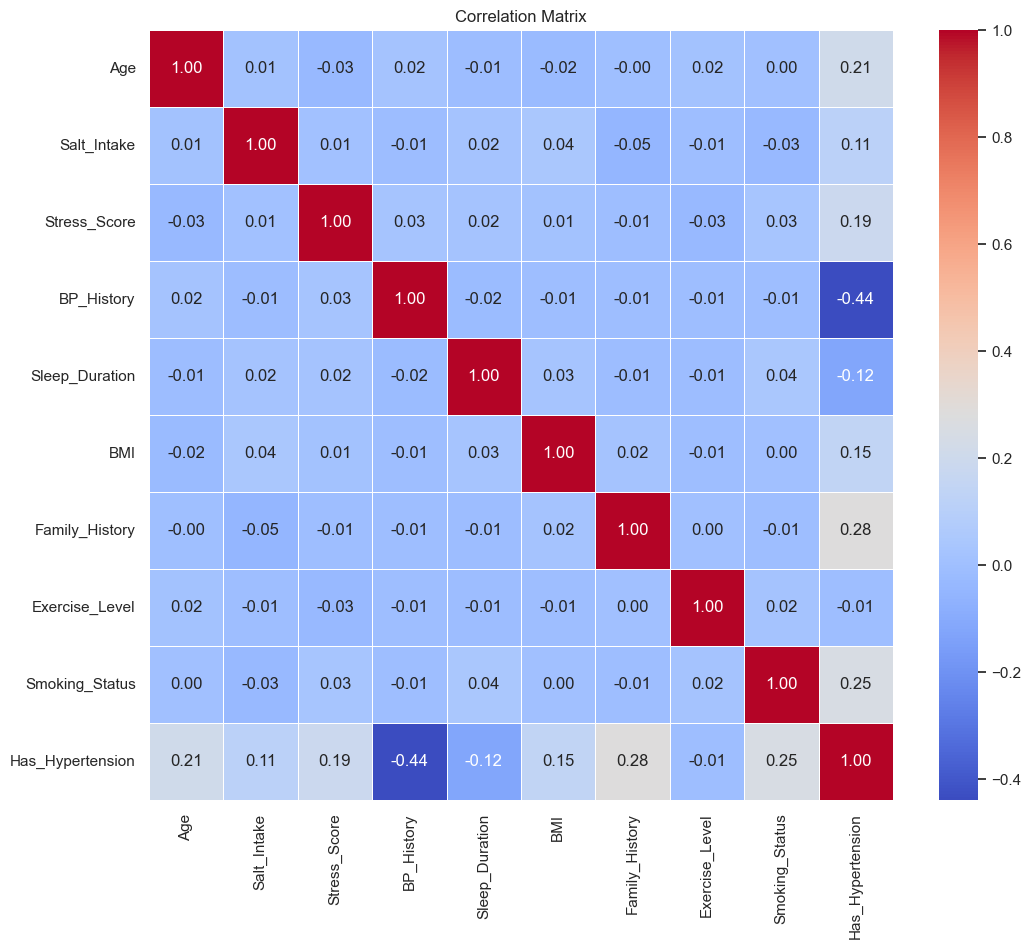

In [68]:
# Corr()

plt.figure(figsize=(12, 10))
# correlation_matrix = df.corr()
sns.heatmap(df_ML.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix')
plt.show()

In [69]:
print("Correlation of Features with Has_Hypertension:")
correlation = df_ML.corr(numeric_only=True)['Has_Hypertension'].sort_values(ascending=False).round(3)
print(correlation)

Correlation of Features with Has_Hypertension:
Has_Hypertension    1.000
Family_History      0.282
Smoking_Status      0.251
Age                 0.211
Stress_Score        0.187
BMI                 0.145
Salt_Intake         0.114
Exercise_Level     -0.007
Sleep_Duration     -0.120
BP_History         -0.439
Name: Has_Hypertension, dtype: float64


### 📖 Import Library Package

In [70]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier

### 🧾Split Data Train/Test

In [71]:
X = df_ML.drop('Has_Hypertension', axis=1)
y = df_ML['Has_Hypertension'] 

print("Features (X) Dimension:", X.shape)
print("Target Variable (y) Dimension:", y.shape)

Features (X) Dimension: (1985, 9)
Target Variable (y) Dimension: (1985,)


In [72]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Training Set Size: {X_train.shape[0]}")
print(f"Test Set Size: {X_test.shape[0]}")

Training Set Size: 1588
Test Set Size: 397


### 📌Modeling 

In [73]:
numeric_cols_for_scaling = ['Age', 'Salt_Intake', 'Stress_Score', 'Sleep_Duration', 'BMI', 'BP_History']

scaler = StandardScaler()
X_train[numeric_cols_for_scaling] = scaler.fit_transform(X_train[numeric_cols_for_scaling])
X_test[numeric_cols_for_scaling] = scaler.transform(X_test[numeric_cols_for_scaling])

In [74]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear'), 
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100), 
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'SVM': SVC(random_state=42, probability=True, kernel='rbf'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'AdaBoost': AdaBoostClassifier(random_state=42, n_estimators=100)
}

trained_models = {}

In [75]:
for name, model in models.items():
    print(f"[{name}] The model is being trained...")
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"[{name}] model training is completed.")
    print()

print("\nAll models were trained successfully.")

[Logistic Regression] The model is being trained...
[Logistic Regression] model training is completed.

[Random Forest] The model is being trained...
[Random Forest] model training is completed.

[XGBoost] The model is being trained...
[XGBoost] model training is completed.

[SVM] The model is being trained...
[SVM] model training is completed.

[Gradient Boosting] The model is being trained...
[Gradient Boosting] model training is completed.

[KNN] The model is being trained...
[KNN] model training is completed.

[AdaBoost] The model is being trained...
[AdaBoost] model training is completed.


All models were trained successfully.


### Evaluation


--- Logistic Regression Evaluating the Model ---
Accuracy: 0.8186
F1 Score: 0.8227
ROC-AUC: 0.9156
Confusion Matrix:
 [[158  33]
 [ 39 167]]


<Figure size 600x500 with 0 Axes>

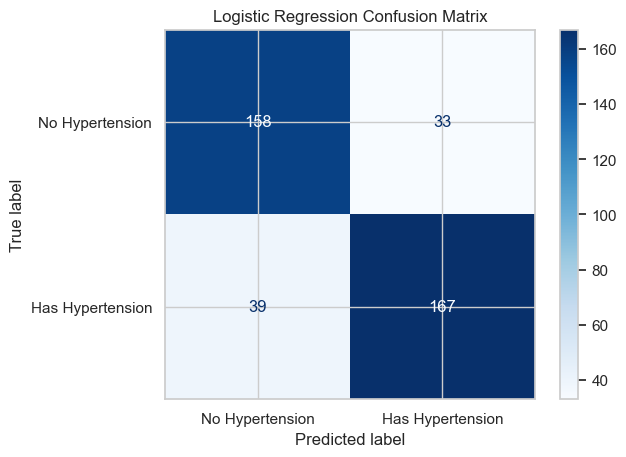


--- Random Forest Evaluating the Model ---
Accuracy: 0.9597
F1 Score: 0.9612
ROC-AUC: 0.9949
Confusion Matrix:
 [[183   8]
 [  8 198]]


<Figure size 600x500 with 0 Axes>

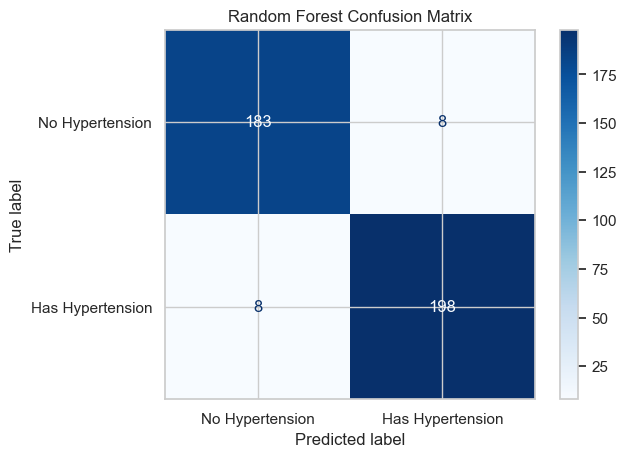


--- XGBoost Evaluating the Model ---
Accuracy: 0.9698
F1 Score: 0.9713
ROC-AUC: 0.9981
Confusion Matrix:
 [[182   9]
 [  3 203]]


<Figure size 600x500 with 0 Axes>

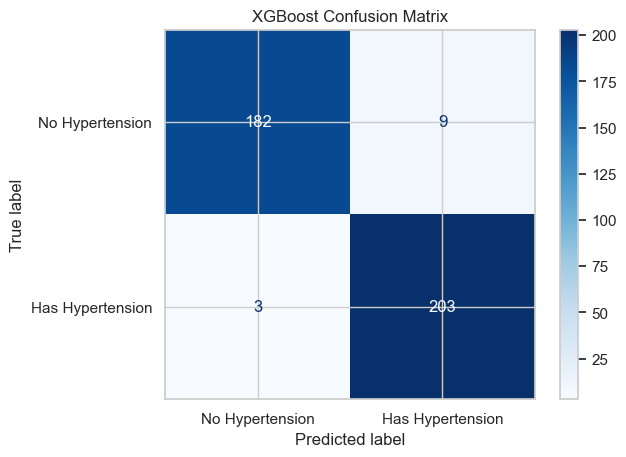


--- SVM Evaluating the Model ---
Accuracy: 0.8942
F1 Score: 0.8960
ROC-AUC: 0.9668
Confusion Matrix:
 [[174  17]
 [ 25 181]]


<Figure size 600x500 with 0 Axes>

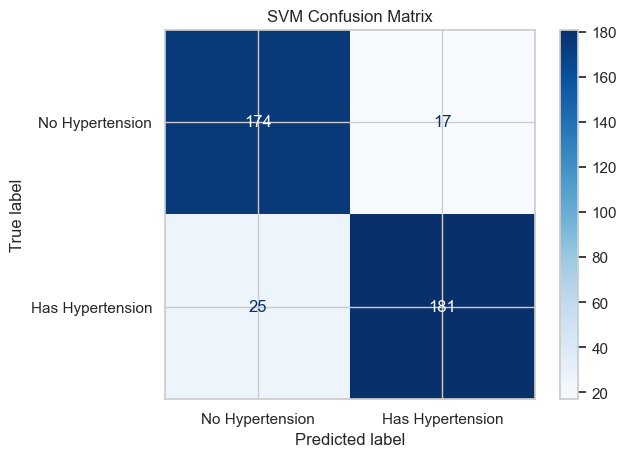


--- Gradient Boosting Evaluating the Model ---
Accuracy: 0.9698
F1 Score: 0.9707
ROC-AUC: 0.9978
Confusion Matrix:
 [[186   5]
 [  7 199]]


<Figure size 600x500 with 0 Axes>

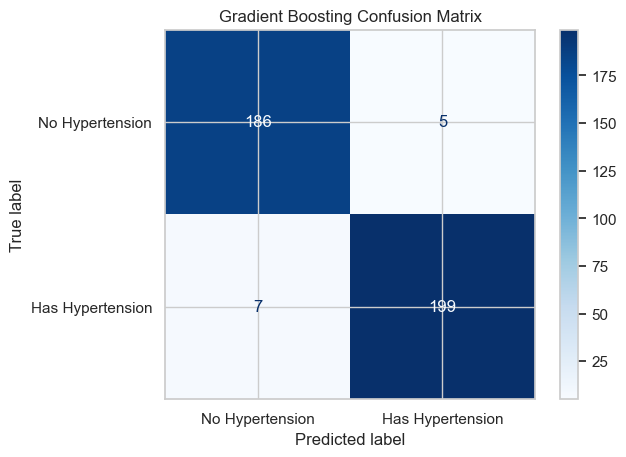


--- KNN Evaluating the Model ---
Accuracy: 0.8413
F1 Score: 0.8355
ROC-AUC: 0.9264
Confusion Matrix:
 [[174  17]
 [ 46 160]]


<Figure size 600x500 with 0 Axes>

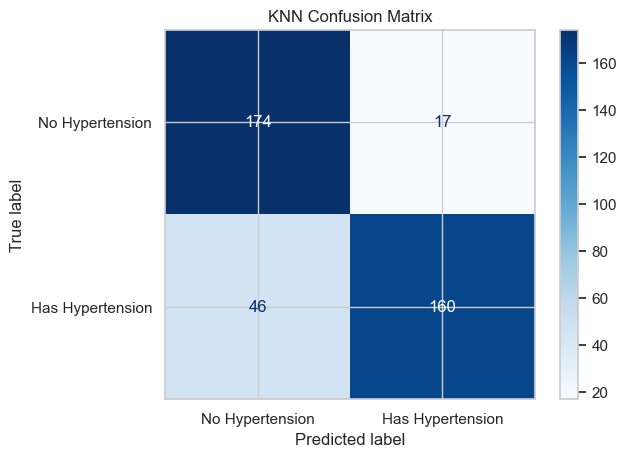


--- AdaBoost Evaluating the Model ---
Accuracy: 0.9975
F1 Score: 0.9976
ROC-AUC: 1.0000
Confusion Matrix:
 [[191   0]
 [  1 205]]


<Figure size 600x500 with 0 Axes>

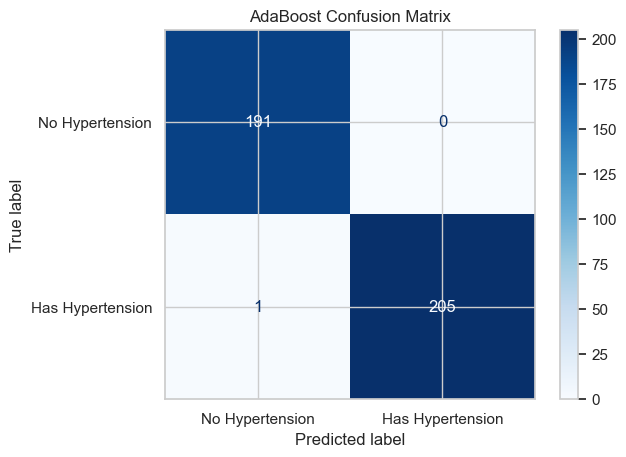

In [76]:
results = {}

for name, model in trained_models.items():
    print(f"\n--- {name} Evaluating the Model ---")

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] 

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)

    results[name] = {
        'Accuracy': accuracy,
        'F1 Score': f1,
        'ROC-AUC': roc_auc,
        'Confusion Matrix': cm
    }

    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print("Confusion Matrix:\n", cm)

    plt.figure(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Hypertension', 'Has Hypertension'])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'{name} Confusion Matrix')
    plt.show()

In [77]:
print("Performance Summary of All Models:\n")
for name, metrics in results.items():
    print(f"Model: {name}")
    print(f"  Accuracy: {metrics['Accuracy']:.4f}")
    print(f"  F1 Score: {metrics['F1 Score']:.4f}")
    print(f"  ROC-AUC: {metrics['ROC-AUC']:.4f}")
    print("-" * 30)

Performance Summary of All Models:

Model: Logistic Regression
  Accuracy: 0.8186
  F1 Score: 0.8227
  ROC-AUC: 0.9156
------------------------------
Model: Random Forest
  Accuracy: 0.9597
  F1 Score: 0.9612
  ROC-AUC: 0.9949
------------------------------
Model: XGBoost
  Accuracy: 0.9698
  F1 Score: 0.9713
  ROC-AUC: 0.9981
------------------------------
Model: SVM
  Accuracy: 0.8942
  F1 Score: 0.8960
  ROC-AUC: 0.9668
------------------------------
Model: Gradient Boosting
  Accuracy: 0.9698
  F1 Score: 0.9707
  ROC-AUC: 0.9978
------------------------------
Model: KNN
  Accuracy: 0.8413
  F1 Score: 0.8355
  ROC-AUC: 0.9264
------------------------------
Model: AdaBoost
  Accuracy: 0.9975
  F1 Score: 0.9976
  ROC-AUC: 1.0000
------------------------------


#### 🔹Bar Plot Model

In [78]:
# Convert results dict to DataFrame
metrics_df = pd.DataFrame(results).T[['Accuracy', 'F1 Score', 'ROC-AUC']]
metrics_df = metrics_df.sort_values('ROC-AUC', ascending=False)

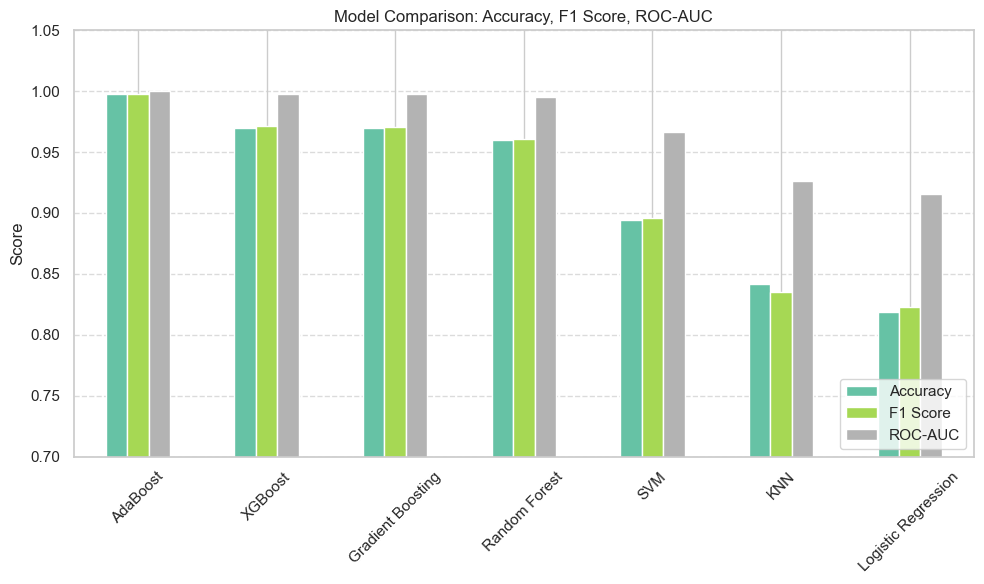

In [79]:
# Plot
metrics_df.plot(kind='bar', figsize=(10, 6), colormap='Set2')
plt.title("Model Comparison: Accuracy, F1 Score, ROC-AUC")
plt.ylabel("Score")
plt.ylim(0.7, 1.05)
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### 🔹ROC Curve

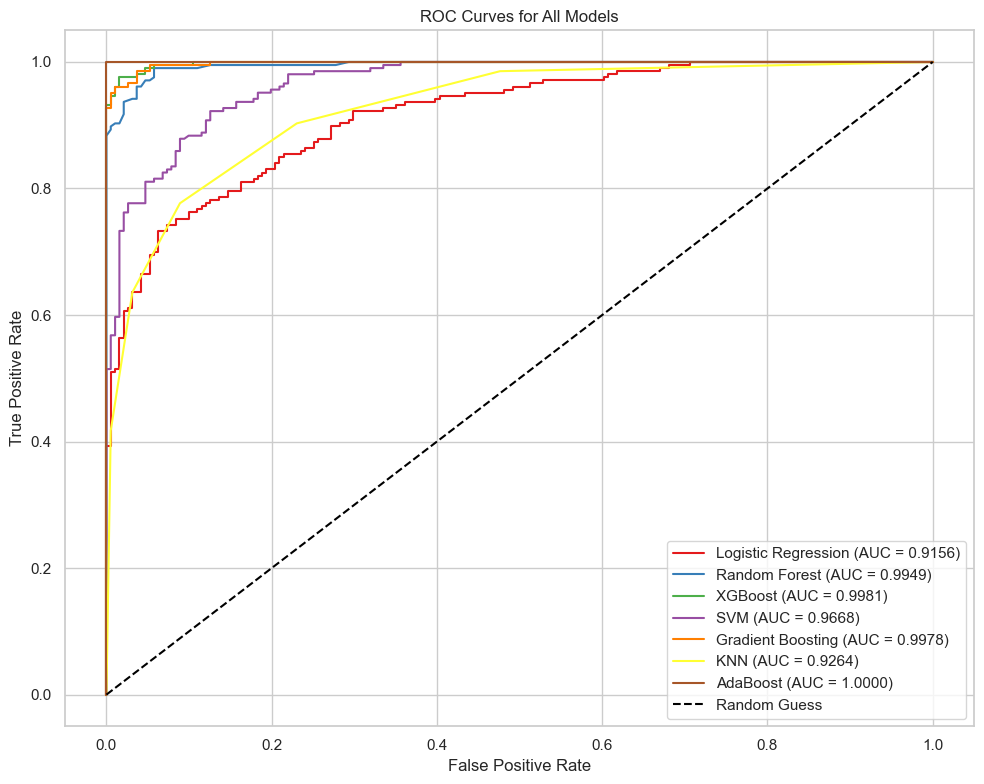

In [80]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

for name, model in trained_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

# Plot reference line
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.title('ROC Curves for All Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

### ⚠️ Feature Importance

#### ✅ Feature Importance – Logistic Regression (Coefficient Magnitude)

In [81]:
# Logistic Regression Coefficient Importance
lr_model = trained_models['Logistic Regression']
lr_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': abs(lr_model.coef_[0])  # Ambil nilai absolut dari koefisien
}).sort_values(by='Importance', ascending=False)

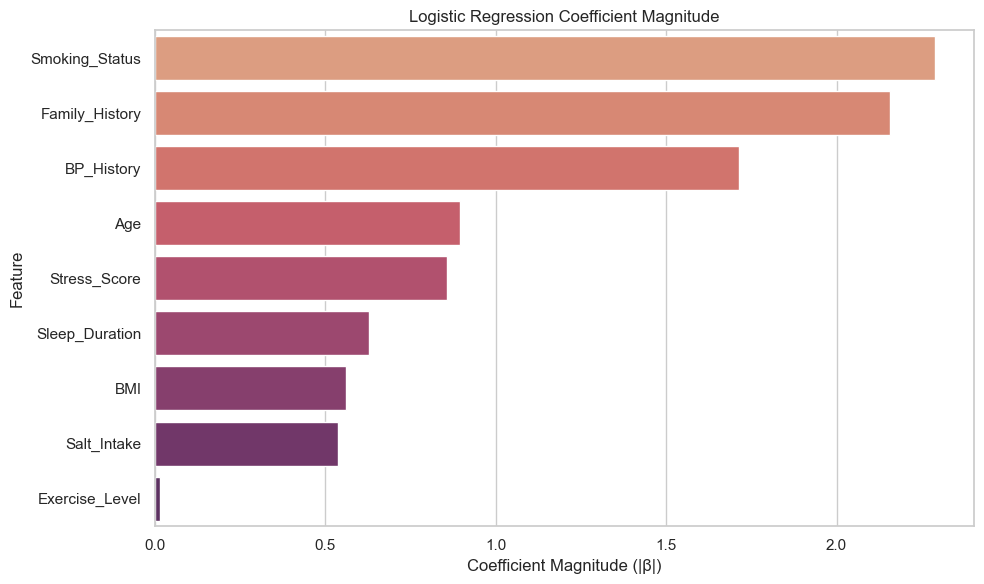

In [82]:
plt.figure(figsize=(10, 6))
sns.barplot(data=lr_importance, x='Importance', y='Feature', hue='Feature', palette='flare')
plt.title('Logistic Regression Coefficient Magnitude')
plt.xlabel('Coefficient Magnitude (|β|)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

#### ✅ Feature Importance – Random Forest

In [83]:
# Random Forest Feature Importance
rf_model = trained_models['Random Forest']
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

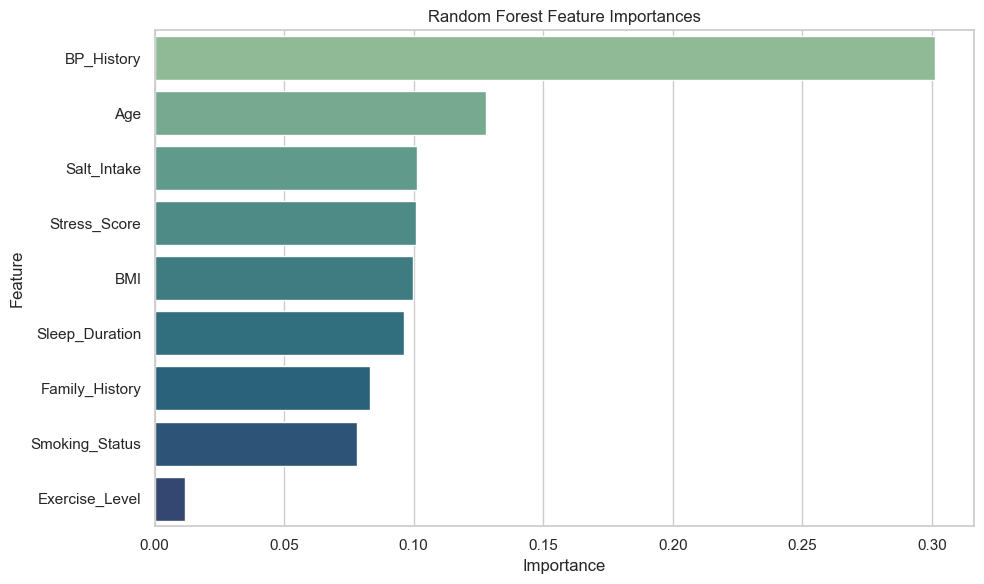

In [84]:
plt.figure(figsize=(10, 6))
sns.barplot(data=rf_importance, x='Importance', y='Feature', hue='Feature', palette='crest')
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

#### ✅Feature Importance – XGBoost

In [85]:
# XGBoost Feature Importance
xgb_model = trained_models['XGBoost']
xgb_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

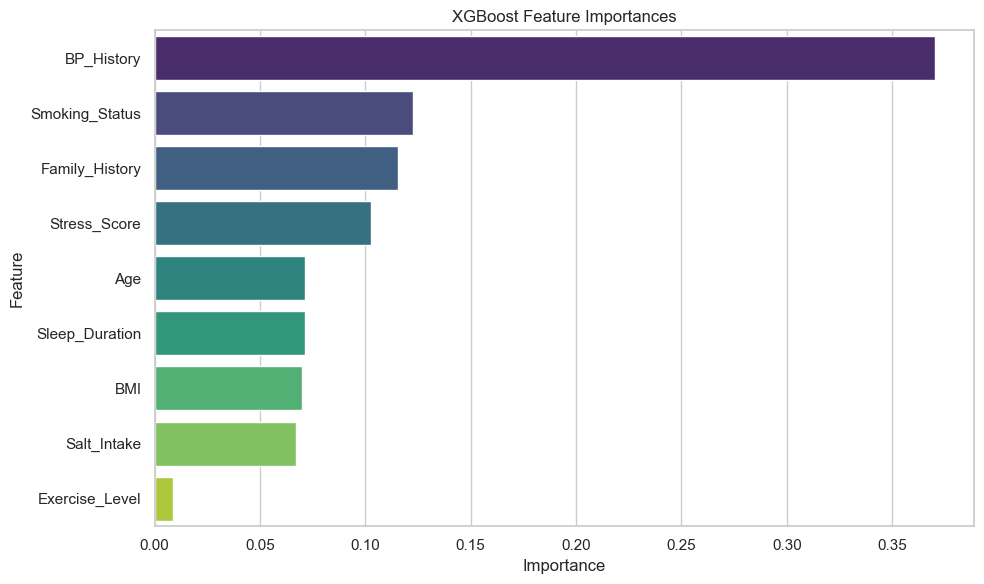

In [86]:
plt.figure(figsize=(10, 6))
sns.barplot(data=xgb_importance, x='Importance', y='Feature', hue='Feature', palette='viridis')
plt.title('XGBoost Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## ✅ 📊 Conclusion

### ⚙️ Ringkasan Performa Model

| Model               | Accuracy | F1 Score | ROC-AUC |
| ------------------- | -------- | -------- | ------- |
| Logistic Regression | 0.8186   | 0.8227   | 0.9156  |
| Random Forest       | 0.9597   | 0.9612   | 0.9949  |
| XGBoost             | 0.9698   | 0.9713   | 0.9981  |

### 🔍 Analisis & Interpretasi

#### 1. Logistic Regression
- It is a simple and interpretable baseline model.
- Accuracy and F1 Score are quite good (around 82%).
- ROC-AUC 0.9156 shows decent classification ability, but it is still far behind the other two models.
- Suitable for situations where interpretability is very important, but a trade-off with performance must be accepted.

#### 2. Random Forest
- Decision tree-based ensemble model.
- Significant performance improvement compared to Logistic Regression: accuracy of nearly 96% and ROC-AUC close to 1.
- High F1 Score indicates the model's ability to handle imbalance (if any) well.
- Excellent at capturing non-linear patterns without too much tuning.

#### 3. XGBoost
- A very powerful gradient boosting model that often excels in ML competitions.
- Best performance across all metrics: 97% accuracy, 97.13% F1 Score, 0.9981 ROC-AUC.
- Well suited for accurate and robust predictions, although with a higher risk of overfitting if not controlled.

### 🧾 Conclusion
1. XGBoost is the **best model in terms of performance**, excelling in all evaluation metrics. It is highly recommended if the main goal is accuracy and prediction efficiency.
2. Random Forest also delivers very strong results and can be an alternative if training time or interpretability is relatively more important.
3. Logistic Regression, though the weakest in terms of metrics, is still worth considering as a baseline or for initial analysis due to its simplicity and ease of explanation.

## 🤖 Machine Learning V.2 Tuning & Evaluation

### Evaluation Model

#### ⚠️ Evaluasi Overfitting

In [87]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

print("==== Overfitting Check ====\n")

for name, model in trained_models.items():
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    y_train_proba = model.predict_proba(X_train)[:, 1]
    y_test_proba = model.predict_proba(X_test)[:, 1]

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)

    train_auc = roc_auc_score(y_train, y_train_proba)
    test_auc = roc_auc_score(y_test, y_test_proba)

    print(f"Model: {name}")
    print(f"  Train Accuracy : {train_acc:.4f} | Test Accuracy : {test_acc:.4f}")
    print(f"  Train F1 Score : {train_f1:.4f} | Test F1 Score : {test_f1:.4f}")
    print(f"  Train ROC-AUC  : {train_auc:.4f} | Test ROC-AUC  : {test_auc:.4f}")
    print("-" * 50)

==== Overfitting Check ====

Model: Logistic Regression
  Train Accuracy : 0.8369 | Test Accuracy : 0.8186
  Train F1 Score : 0.8433 | Test F1 Score : 0.8227
  Train ROC-AUC  : 0.9141 | Test ROC-AUC  : 0.9156
--------------------------------------------------
Model: Random Forest
  Train Accuracy : 1.0000 | Test Accuracy : 0.9597
  Train F1 Score : 1.0000 | Test F1 Score : 0.9612
  Train ROC-AUC  : 1.0000 | Test ROC-AUC  : 0.9949
--------------------------------------------------
Model: XGBoost
  Train Accuracy : 1.0000 | Test Accuracy : 0.9698
  Train F1 Score : 1.0000 | Test F1 Score : 0.9713
  Train ROC-AUC  : 1.0000 | Test ROC-AUC  : 0.9981
--------------------------------------------------
Model: SVM
  Train Accuracy : 0.9351 | Test Accuracy : 0.8942
  Train F1 Score : 0.9373 | Test F1 Score : 0.8960
  Train ROC-AUC  : 0.9862 | Test ROC-AUC  : 0.9668
--------------------------------------------------
Model: Gradient Boosting
  Train Accuracy : 0.9987 | Test Accuracy : 0.9698
  Tra

#### ⚠️ Validasi Silang (Stratified K-Fold Cross-Validation)

In [88]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

In [89]:
print("\n==== Cross-Validation (StratifiedKFold) ====\n")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in trained_models.items():
    auc_scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')
    f1_scores = cross_val_score(model, X, y, cv=cv, scoring='f1')
    acc_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')

    print(f"Model: {name}")
    print(f"  Mean Accuracy : {acc_scores.mean():.4f} ± {acc_scores.std():.4f}")
    print(f"  Mean F1 Score : {f1_scores.mean():.4f} ± {f1_scores.std():.4f}")
    print(f"  Mean ROC-AUC  : {auc_scores.mean():.4f} ± {auc_scores.std():.4f}")
    print("-" * 50)


==== Cross-Validation (StratifiedKFold) ====

Model: Logistic Regression
  Mean Accuracy : 0.8237 ± 0.0102
  Mean F1 Score : 0.8301 ± 0.0130
  Mean ROC-AUC  : 0.9116 ± 0.0062
--------------------------------------------------
Model: Random Forest
  Mean Accuracy : 0.9683 ± 0.0076
  Mean F1 Score : 0.9692 ± 0.0072
  Mean ROC-AUC  : 0.9964 ± 0.0020
--------------------------------------------------
Model: XGBoost
  Mean Accuracy : 0.9899 ± 0.0023
  Mean F1 Score : 0.9903 ± 0.0023
  Mean ROC-AUC  : 0.9987 ± 0.0007
--------------------------------------------------
Model: SVM
  Mean Accuracy : 0.6917 ± 0.0203
  Mean F1 Score : 0.7135 ± 0.0168
  Mean ROC-AUC  : 0.7744 ± 0.0171
--------------------------------------------------
Model: Gradient Boosting
  Mean Accuracy : 0.9889 ± 0.0057
  Mean F1 Score : 0.9893 ± 0.0055
  Mean ROC-AUC  : 0.9991 ± 0.0011
--------------------------------------------------
Model: KNN
  Mean Accuracy : 0.6776 ± 0.0244
  Mean F1 Score : 0.6706 ± 0.0264
  Mean ROC

#### 📋 Summary Overfitting and Cross Validation Report

##### 🔍 1. Healthy & Consistent Models
> Models with balanced training and testing performance, as well as high and stable cross-validation scores:  

✅ Logistic Regression
- Stable and balanced: train and test scores are quite close
- CV score is also quite high (ROC-AUC ~0.91)
- Not overfitted, high interpretability → suitable for baseline models and feature analysis

##### ⚠️ 2. Very Accurate Model but Prone to Overfitting

🔶 **Random Forest & XGBoost & Gradient Boosting**  
- Train Score = 1.0 → indication of overfitting
- However, the test score and CV score are also high, so the overfitting is controlled.
- However, the margin between train and test is quite large, so it is necessary to:
- Regularization (max_depth, min_samples_split)
- Hyperparameter tuning (GridSearchCV, early stopping)  

🧠 Conclusion  
→ Still valid for use, but **do not deploy without tuning.**

##### 🚩 3. Model is highly overfit/unrealistic

🔴 **AdaBoost**  
All scores are perfect (1.0), both train, test, and CV → this is abnormal.  

Highly likely to occur:
- 🔍 Data leakage
- 💥 Target leakage
- 📉 Or, the model is learning something it shouldn't (features are too easy to learn, there are duplicate data, or leakage from feature engineering)

🧠 Conclusion:
❗️Must investigate. **For now, do not use this model.**

##### ❌ 4. Underfit/Inconsistent Models

🟡 **KNN and SVM**
> Both have a large gap between train and test, as well as low CV scores.  

KNN:
- High train acc, low test → overfit
- CV ROC-AUC ~0.73 → low  
SVM:
- CV ROC-AUC ~0.77, but high test score → may be too sensitive to distribution.  

🧠 Conclusion:
- Can be kept for experimentation, but not a top candidate
- Try tuning C (SVM) and n_neighbors (KNN)

##### 📌 Summary and Recomendations
| Model               | Status             | Catatan                                                                 |
| ------------------- | ------------------ | ----------------------------------------------------------------------- |
| Logistic Regression | ✅ Good             | Balanced and stable. Suitable for baseline.                            |
| Random Forest       | ✅ Slight overfitting   | Valid, but needs tuning to prevent overfitting.                        |
| XGBoost             | ✅ Slight overfitting   | Top performance, but needs regularization.                              |
| Gradient Boosting   | ✅ Slight overfitting   | Just like XGBoost, tunable.                                          |
| AdaBoost            | ❌ Danger           | The score is too perfect → possibility of **data leakage** or model error.  |
| SVM                 | ⚠️ Weak           | CV score is too low. Needs tuning or dropping.                        |
| KNN                 | ⚠️ Overfit / Weak | The model does not generalize well. Try tuning or changing the algorithm.|

#### 📊 Visualisasi Cross-Validation Scores (Boxplot)

In [90]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Inisialisasi list untuk menyimpan skor
cv_scores_auc = []
cv_scores_acc = []

# Hitung cross-val scores per model
for name, model in trained_models.items():
    auc = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')
    acc = cross_val_score(model, X, y, cv=cv, scoring='accuracy')

    for score in auc:
        cv_scores_auc.append({'Model': name, 'Score': score, 'Metric': 'ROC-AUC'})
    for score in acc:
        cv_scores_acc.append({'Model': name, 'Score': score, 'Metric': 'Accuracy'})

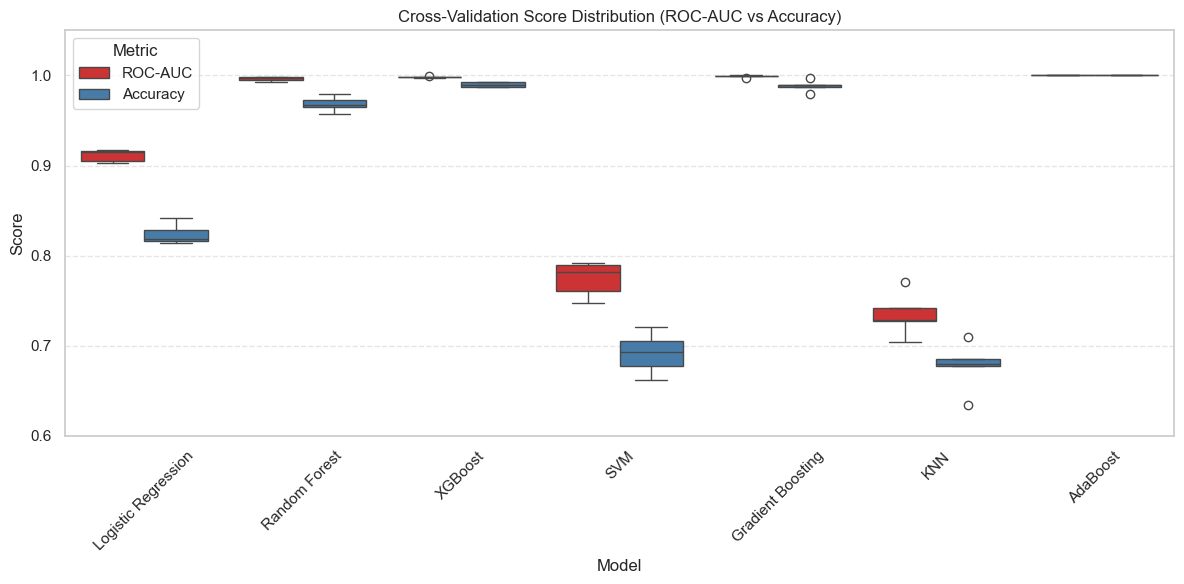

In [100]:
# Gabungkan ke DataFrame
cv_df = pd.DataFrame(cv_scores_auc + cv_scores_acc)

# Plot boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=cv_df, x='Model', y='Score', hue='Metric')
plt.title('Cross-Validation Score Distribution (ROC-AUC vs Accuracy)')
plt.xticks(rotation=45)
plt.ylim(0.6, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### 📊 Learning Curve dan Validation Curve

In [91]:
from sklearn.model_selection import learning_curve

In [93]:
xgb_model = trained_models['XGBoost']

train_sizes, train_scores, test_scores = learning_curve(
    xgb_model, X, y,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

train_scores_mean = train_scores.mean(axis=1)
test_scores_mean = test_scores.mean(axis=1)

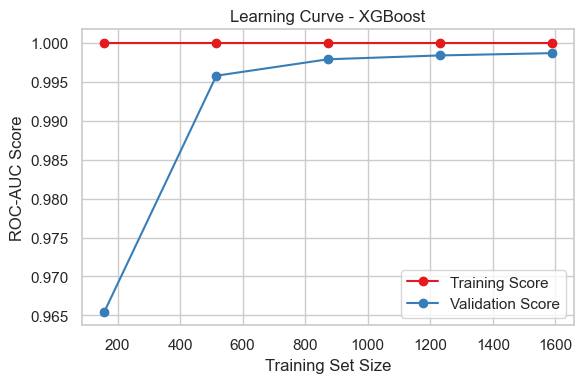

In [109]:
# Plot learning curve
plt.figure(figsize=(6, 4))
plt.plot(train_sizes, train_scores_mean, label='Training Score', marker='o')
plt.plot(train_sizes, test_scores_mean, label='Validation Score', marker='o')
plt.title('Learning Curve - XGBoost')
plt.xlabel('Training Set Size')
plt.ylabel('ROC-AUC Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### Validation Curve untuk XGBoost (n_estimators)

In [95]:
from sklearn.model_selection import validation_curve

In [96]:
param_range = [10, 50, 100, 150, 200]
train_scores, val_scores = validation_curve(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    X, y,
    param_name='n_estimators',
    param_range=param_range,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

In [97]:
# Rata-rata skor
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

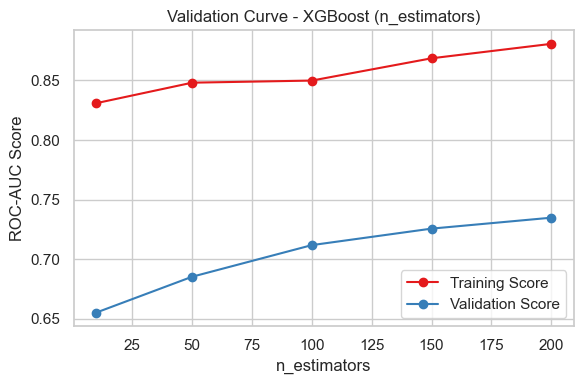

In [108]:
# Plot validation curve
plt.figure(figsize=(6, 4))
plt.plot(param_range, train_mean, label='Training Score', marker='o')
plt.plot(param_range, val_mean, label='Validation Score', marker='o')
plt.title('Validation Curve - XGBoost (n_estimators)')
plt.xlabel('n_estimators')
plt.ylabel('ROC-AUC Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### ✅ Learning Curve Semua Model

Plotting Learning Curve for: Logistic Regression


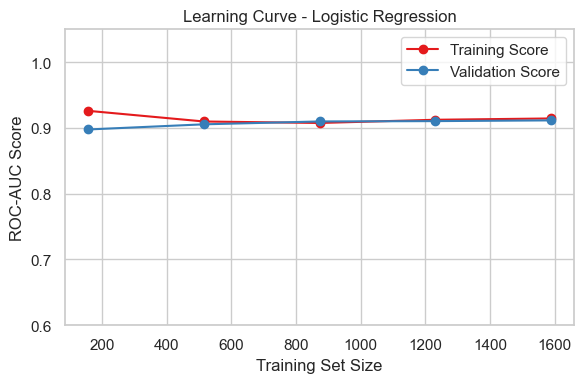

Plotting Learning Curve for: Random Forest


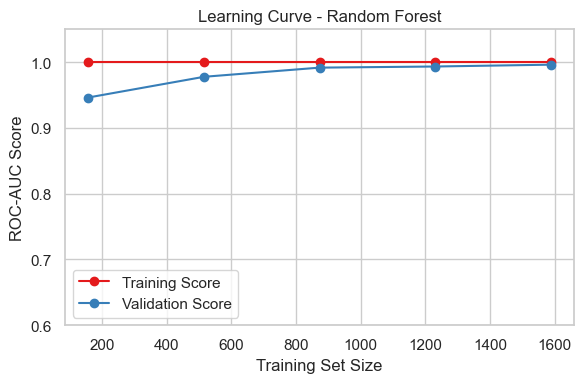

Plotting Learning Curve for: XGBoost


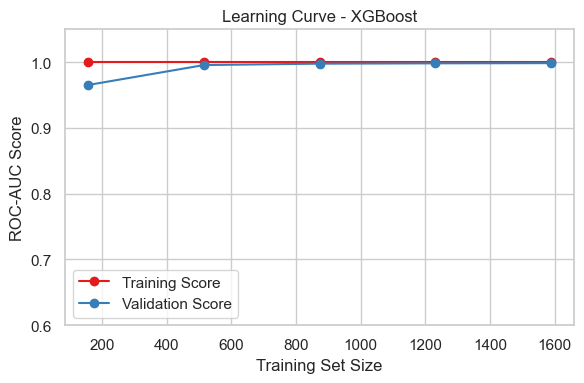

Plotting Learning Curve for: SVM


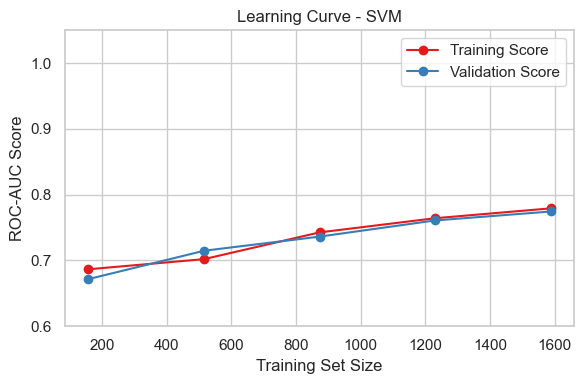

Plotting Learning Curve for: Gradient Boosting


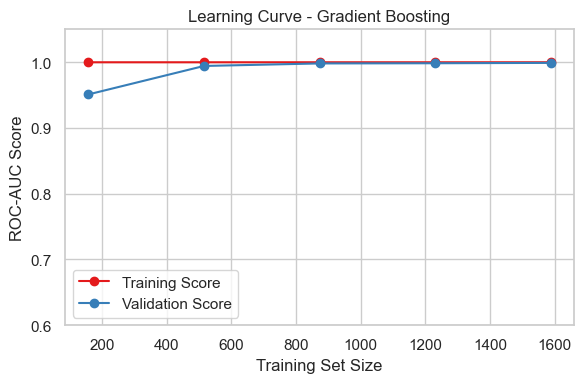

Plotting Learning Curve for: KNN


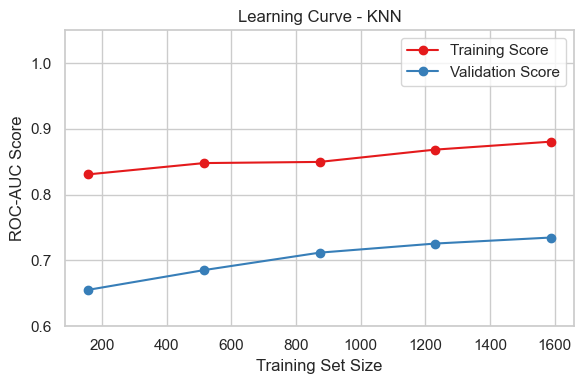

Plotting Learning Curve for: AdaBoost


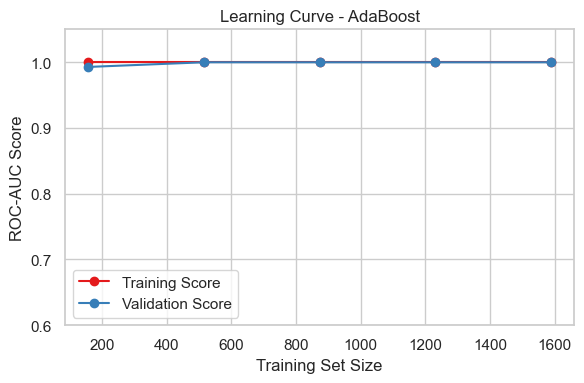

In [110]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in trained_models.items():
    print(f"Plotting Learning Curve for: {name}")
    
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        train_sizes=np.linspace(0.1, 1.0, 5),
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1
    )
    
    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)
    
    plt.figure(figsize=(6, 4))
    plt.plot(train_sizes, train_mean, label='Training Score', marker='o')
    plt.plot(train_sizes, val_mean, label='Validation Score', marker='o')
    plt.title(f'Learning Curve - {name}')
    plt.xlabel('Training Set Size')
    plt.ylabel('ROC-AUC Score')
    plt.ylim(0.6, 1.05)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

#### ✅ Validation Curve (Parameter Spesifik) - All Model

In [102]:
from sklearn.model_selection import validation_curve

param_config = {
    'XGBoost': {
        'param_name': 'n_estimators',
        'param_range': [10, 50, 100, 150, 200],
        'model': XGBClassifier(random_state=42, eval_metric='logloss')
    },
    'Random Forest': {
        'param_name': 'n_estimators',
        'param_range': [10, 50, 100, 150, 200],
        'model': RandomForestClassifier(random_state=42)
    },
    'Gradient Boosting': {
        'param_name': 'n_estimators',
        'param_range': [10, 50, 100, 150, 200],
        'model': GradientBoostingClassifier(random_state=42)
    },
    'AdaBoost': {
        'param_name': 'n_estimators',
        'param_range': [10, 50, 100, 150, 200],
        'model': AdaBoostClassifier(random_state=42)
    },
    'Logistic Regression': {
        'param_name': 'C',
        'param_range': [0.01, 0.1, 1, 10, 100],
        'model': LogisticRegression(solver='liblinear', random_state=42)
    },
    'SVM': {
        'param_name': 'C',
        'param_range': [0.01, 0.1, 1, 10, 100],
        'model': SVC(probability=True, random_state=42)
    }
}

Validation Curve for: XGBoost (n_estimators)


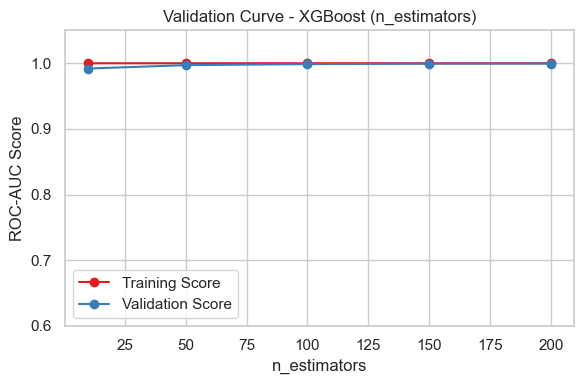

Validation Curve for: Random Forest (n_estimators)


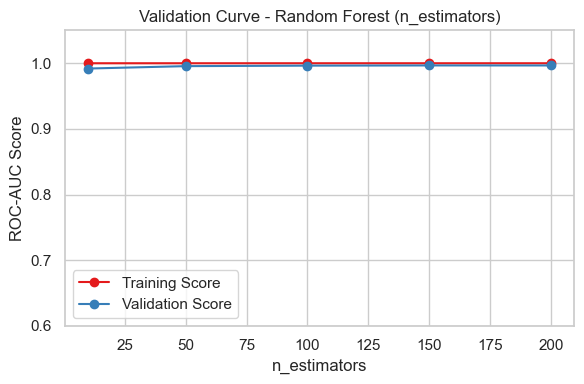

Validation Curve for: Gradient Boosting (n_estimators)


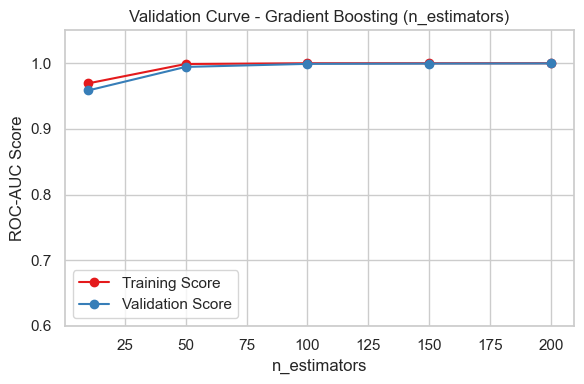

Validation Curve for: AdaBoost (n_estimators)


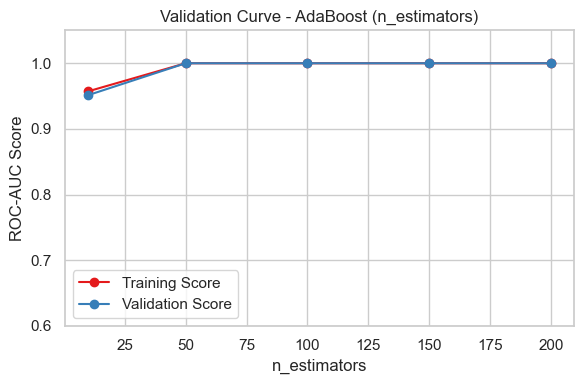

Validation Curve for: Logistic Regression (C)


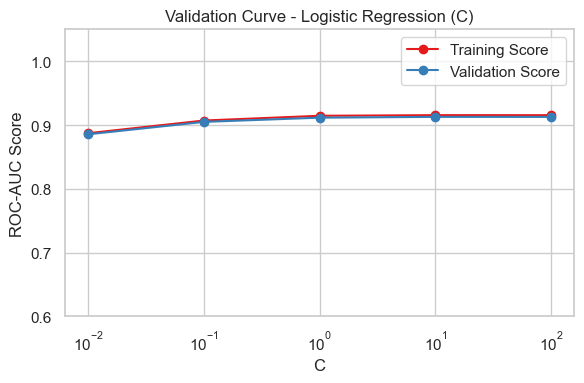

Validation Curve for: SVM (C)


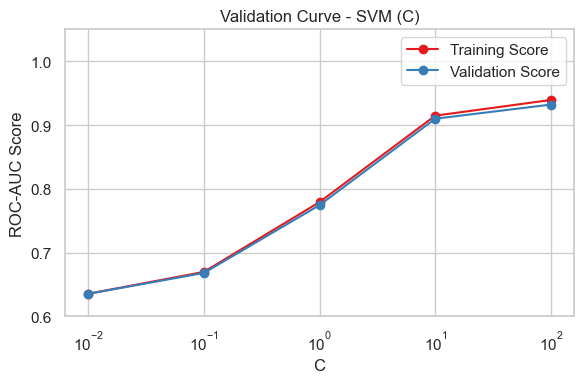

In [104]:
for name, config in param_config.items():
    print(f"Validation Curve for: {name} ({config['param_name']})")

    train_scores, val_scores = validation_curve(
        config['model'],
        X, y,
        param_name=config['param_name'],
        param_range=config['param_range'],
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1
    )
    
    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)
    
    plt.figure(figsize=(6, 4))
    plt.plot(config['param_range'], train_mean, label='Training Score', marker='o')
    plt.plot(config['param_range'], val_mean, label='Validation Score', marker='o')
    plt.title(f'Validation Curve - {name} ({config["param_name"]})')
    plt.xlabel(config['param_name'])
    plt.ylabel('ROC-AUC Score')
    plt.xscale('log') if config['param_name'] == 'C' else None
    plt.ylim(0.6, 1.05)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

#### ✅ Learning Curve - Model KNN

In [105]:
knn_model = trained_models['KNN']  # Ambil model dari yang sudah kamu latih
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_sizes, train_scores, val_scores = learning_curve(
    knn_model, X, y,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

In [106]:
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

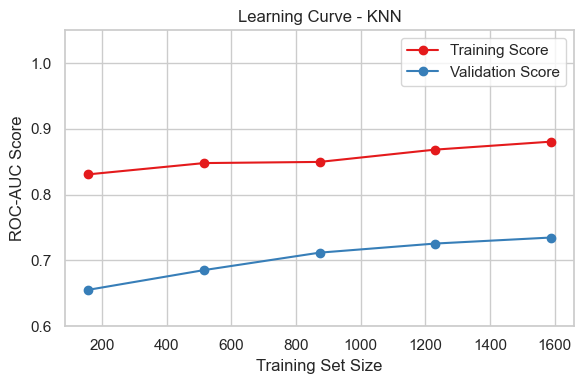

In [107]:
plt.figure(figsize=(6, 4))
plt.plot(train_sizes, train_mean, label='Training Score', marker='o')
plt.plot(train_sizes, val_mean, label='Validation Score', marker='o')
plt.title('Learning Curve - KNN')
plt.xlabel('Training Set Size')
plt.ylabel('ROC-AUC Score')
plt.ylim(0.6, 1.05)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### GridSearchCV

#### Library

In [111]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

#### ✅ Prepare Parameter Grid & Model

In [112]:
# Konfigurasi model dan grid
grid_configs = {
    'Logistic Regression': {
        'model': LogisticRegression(solver='liblinear', random_state=42),
        'params': {
            'C': [0.01, 0.1, 1, 10]
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100],
            'max_depth': [None, 10, 20],
            'min_samples_split': [2, 5]
        }
    },
    'XGBoost': {
        'model': XGBClassifier(random_state=42, eval_metric='logloss'),
        'params': {
            'n_estimators': [50, 100],
            'max_depth': [3, 5],
            'learning_rate': [0.1, 0.3],
            'subsample': [0.8, 1.0]
        }
    },
    'Gradient Boosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100],
            'max_depth': [3, 5],
            'learning_rate': [0.1, 0.3]
        }
    },
    'AdaBoost': {
        'model': AdaBoostClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100],
            'learning_rate': [0.1, 1.0]
        }
    },
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [3, 5, 7],
            'weights': ['uniform', 'distance']
        }
    },
    'SVM': {
        'model': SVC(probability=True, random_state=42),
        'params': {
            'C': [0.1, 1, 10],
            'kernel': ['linear', 'rbf']
        }
    }
}

#### ✅ Grid Search Loop for All Model

In [113]:
import warnings
warnings.filterwarnings('ignore')

best_models = {}

for name, config in grid_configs.items():
    print(f"\n🔍 Tuning {name}...")

    grid = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        scoring='roc_auc',
        cv=5,
        n_jobs=-1,
        verbose=0
    )
    
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    y_pred_proba = best_model.predict_proba(X_test)[:, 1]
    auc_score = roc_auc_score(y_test, y_pred_proba)

    best_models[name] = best_model

    print(f"✅ Best Parameters: {grid.best_params_}")
    print(f"🏆 Test ROC-AUC Score: {auc_score:.4f}")


🔍 Tuning Logistic Regression...
✅ Best Parameters: {'C': 10}
🏆 Test ROC-AUC Score: 0.9159

🔍 Tuning Random Forest...
✅ Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
🏆 Test ROC-AUC Score: 0.9958

🔍 Tuning XGBoost...
✅ Best Parameters: {'learning_rate': 0.3, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
🏆 Test ROC-AUC Score: 0.9990

🔍 Tuning Gradient Boosting...
✅ Best Parameters: {'learning_rate': 0.3, 'max_depth': 3, 'n_estimators': 100}
🏆 Test ROC-AUC Score: 0.9992

🔍 Tuning AdaBoost...
✅ Best Parameters: {'learning_rate': 1.0, 'n_estimators': 100}
🏆 Test ROC-AUC Score: 1.0000

🔍 Tuning KNN...
✅ Best Parameters: {'n_neighbors': 7, 'weights': 'distance'}
🏆 Test ROC-AUC Score: 0.9373

🔍 Tuning SVM...
✅ Best Parameters: {'C': 10, 'kernel': 'rbf'}
🏆 Test ROC-AUC Score: 0.9714


### Evaluation

#### ✅ Evaluasi dan Simpan Metrik Model
Calculate:
- Accuracy
- F1 Score
- ROC-AUC
- Confusion Matrix 

In [114]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

In [115]:
tuned_results = {}

for name, model in best_models.items():
    print(f"\n📊 Evaluating: {name}")
    
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)

    tuned_results[name] = {
        'Accuracy': acc,
        'F1 Score': f1,
        'ROC-AUC': auc,
        'Confusion Matrix': cm,
        'y_pred': y_pred,
        'y_proba': y_proba
    }

    print(f"Accuracy : {acc:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")
    print("Confusion Matrix:\n", cm)


📊 Evaluating: Logistic Regression
Accuracy : 0.8186
F1 Score : 0.8227
ROC-AUC  : 0.9159
Confusion Matrix:
 [[158  33]
 [ 39 167]]

📊 Evaluating: Random Forest
Accuracy : 0.9647
F1 Score : 0.9660
ROC-AUC  : 0.9958
Confusion Matrix:
 [[184   7]
 [  7 199]]

📊 Evaluating: XGBoost
Accuracy : 0.9975
F1 Score : 0.9976
ROC-AUC  : 0.9990
Confusion Matrix:
 [[191   0]
 [  1 205]]

📊 Evaluating: Gradient Boosting
Accuracy : 0.9899
F1 Score : 0.9903
ROC-AUC  : 0.9992
Confusion Matrix:
 [[189   2]
 [  2 204]]

📊 Evaluating: AdaBoost
Accuracy : 0.9975
F1 Score : 0.9976
ROC-AUC  : 1.0000
Confusion Matrix:
 [[191   0]
 [  1 205]]

📊 Evaluating: KNN
Accuracy : 0.8363
F1 Score : 0.8294
ROC-AUC  : 0.9373
Confusion Matrix:
 [[174  17]
 [ 48 158]]

📊 Evaluating: SVM
Accuracy : 0.9093
F1 Score : 0.9122
ROC-AUC  : 0.9714
Confusion Matrix:
 [[174  17]
 [ 19 187]]


#### ✅ Visualisasi Confusion Matrix (Semua Model)

<Figure size 500x400 with 0 Axes>

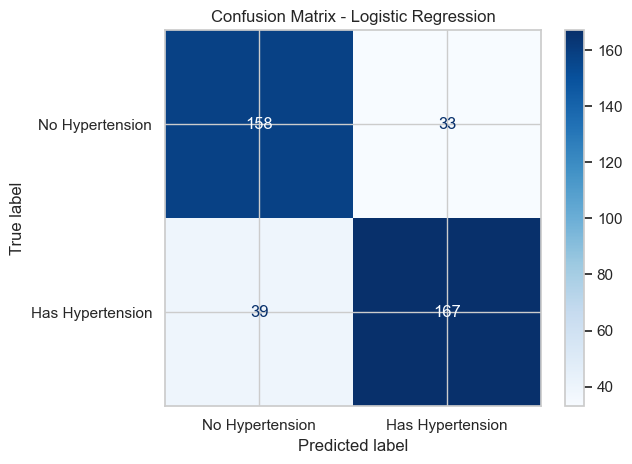

<Figure size 500x400 with 0 Axes>

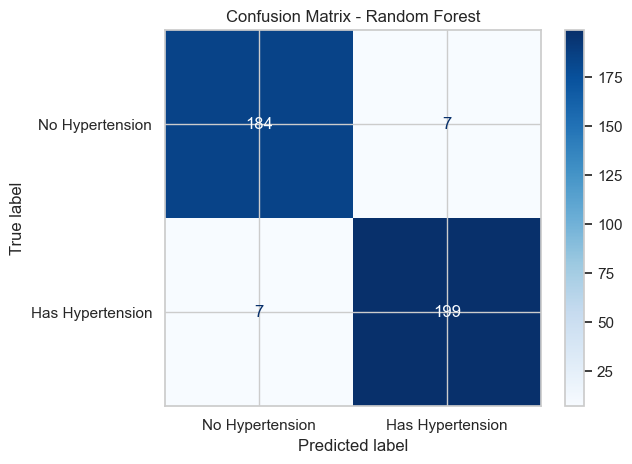

<Figure size 500x400 with 0 Axes>

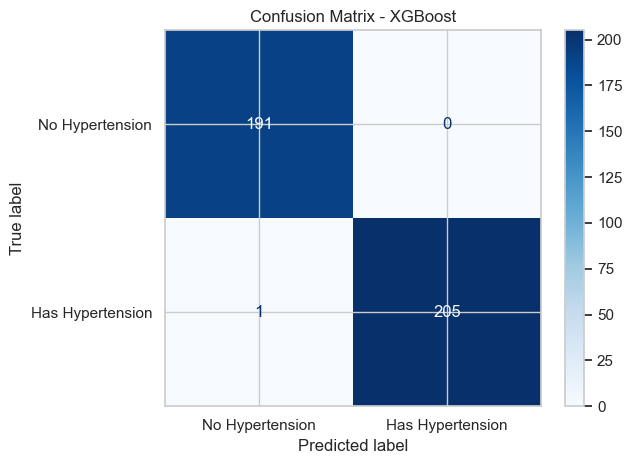

<Figure size 500x400 with 0 Axes>

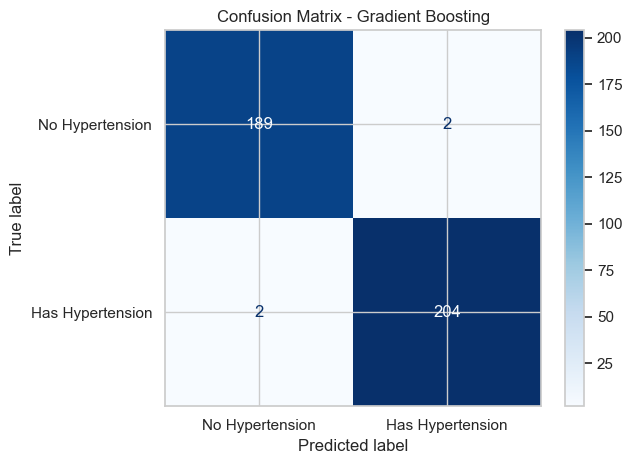

<Figure size 500x400 with 0 Axes>

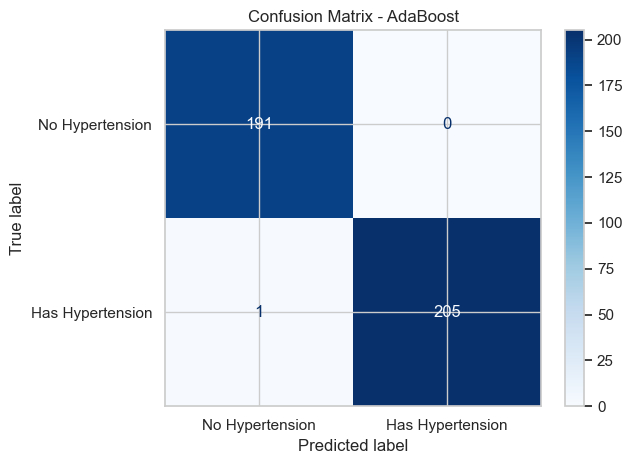

<Figure size 500x400 with 0 Axes>

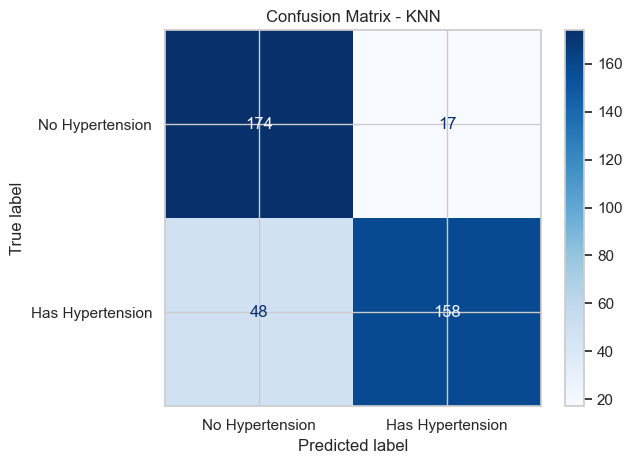

<Figure size 500x400 with 0 Axes>

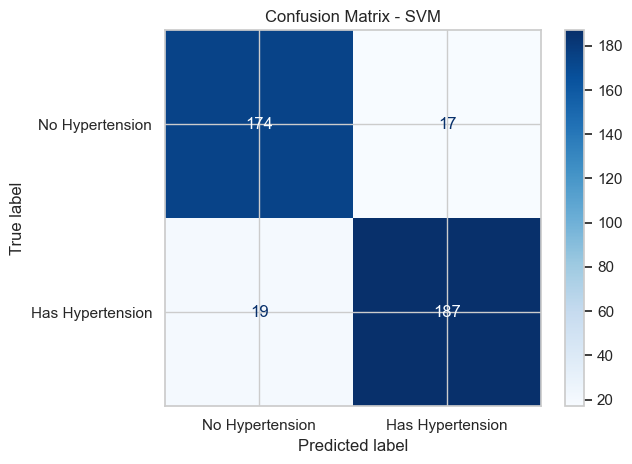

In [116]:
for name, metrics in tuned_results.items():
    cm = metrics['Confusion Matrix']
    
    plt.figure(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Hypertension', 'Has Hypertension'])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'Confusion Matrix - {name}')
    plt.tight_layout()
    plt.show()

#### ✅ Plot ROC Curve Semua Model dalam 1 Grafik

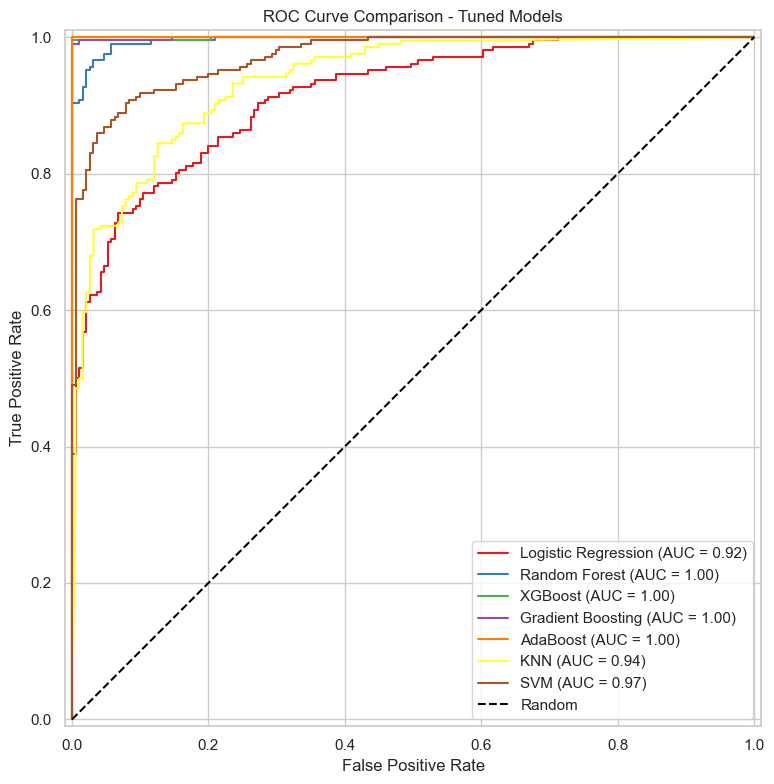

In [117]:
plt.figure(figsize=(10, 8))

for name, metrics in tuned_results.items():
    RocCurveDisplay.from_predictions(
        y_test,
        metrics['y_proba'],
        name=name,
        ax=plt.gca()
    )

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.title('ROC Curve Comparison - Tuned Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

#### ✅ Summary Tabel Performansi Model (Opsional)

In [118]:
summary_df = pd.DataFrame([
    {
        'Model': name,
        'Accuracy': round(metrics['Accuracy'], 4),
        'F1 Score': round(metrics['F1 Score'], 4),
        'ROC-AUC': round(metrics['ROC-AUC'], 4)
    }
    for name, metrics in tuned_results.items()
]).sort_values(by='ROC-AUC', ascending=False)

print("📈 Model Performance Summary (After Tuning):")
display(summary_df)

📈 Model Performance Summary (After Tuning):


,Model,Accuracy,F1 Score,ROC-AUC
4,AdaBoost,0.9975,0.9976,1.0000
3,Gradient Boosting,0.9899,0.9903,0.9992
2,XGBoost,0.9975,0.9976,0.9990
1,Random Forest,0.9647,0.9660,0.9958
6,SVM,0.9093,0.9122,0.9714
5,KNN,0.8363,0.8294,0.9373
0,Logistic Regression,0.8186,0.8227,0.9159


## Deployment

### ✅ Save Model XGBoost ke File

In [119]:
import joblib

# Misalnya XGBoost model sudah dilatih dan tersimpan dalam variabel ini
xgb_model = best_models['XGBoost']  # atau trained_models['XGBoost'] jika belum pakai tuning

# Simpan model ke file .pkl
joblib.dump(xgb_model, 'xgboost_model.pkl')
print("‼️ XGBoost model has been saved as xgboost_model.pkl")

✅ XGBoost model has been saved as xgboost_model.pkl


### ✅ Simpan Scaler (StandardScaler)

In [120]:
joblib.dump(scaler, 'scaler.pkl')
print("⚠️ Scaler has been saved as scaler.pkl")

✅ Scaler has been saved as scaler.pkl


### ✅ Load Model & Scaler untuk Prediksi (Deploy/Testing)

In [121]:
# Load kembali model dan scaler
loaded_model = joblib.load('xgboost_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')

In [122]:
sample_data = pd.DataFrame([{
    'Age': 52,
    'Salt_Intake': 12.0,
    'Stress_Score': 8,
    'Sleep_Duration': 5.5,
    'BMI': 31.2,
    'BP_History': 2,           # Hypertension (hasil label encoding)
    'Family_History': 1,       # Yes (hasil label encoding)
    'Exercise_Level': 0,       # Low
    'Smoking_Status': 1        # Smoker
}])

In [126]:
# Pastikan semua fitur sama urutan & namanya
sample_data = sample_data[X.columns]

In [128]:
# Transformasi fitur numerik
sample_data[numeric_cols_for_scaling] = loaded_scaler.transform(sample_data[numeric_cols_for_scaling])

In [129]:
# Scaling untuk kolom numerik (harus sama dengan saat training)
numeric_cols_for_scaling = ['Age', 'Salt_Intake', 'Stress_Score', 'Sleep_Duration', 'BMI', 'BP_History']
sample_data[numeric_cols_for_scaling] = loaded_scaler.transform(sample_data[numeric_cols_for_scaling])

In [130]:
sample_data

,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Family_History,Exercise_Level,Smoking_Status
0,-2.726864,-7.130672,-2.200558,-2.529014,-9.075345,-7.269569,1,0,1


In [131]:
# Prediksi
predicted_class = loaded_model.predict(sample_data)[0]
predicted_proba = loaded_model.predict_proba(sample_data)[:, 1][0]

In [132]:
print("🩺 Prediction:", "Has Hypertension" if predicted_class == 1 else "No Hypertension")
print("📊 Prediction Probability:", round(predicted_proba, 4))

🩺 Prediction: Has Hypertension
📊 Prediction Probability: 1.0
